<a href="https://www.kaggle.com/code/lalit7881/dog-adoption-success-eda-85?scriptVersionId=339456085" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/sergionefedov/dog-adoption-success-does-the-match-last/data_dictionary.csv
/kaggle/input/datasets/sergionefedov/dog-adoption-success-does-the-match-last/dog_adoption_master.csv


In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')  # Use non-interactive backend
import matplotlib.pyplot as plt
plt.switch_backend('Agg')  # If using only plt, then switch backend
%matplotlib inline

import seaborn as sns

from pathlib import Path

# For predictive modeling
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc
from sklearn.inspection import permutation_importance

sns.set(style="whitegrid")
print('Imports and setup complete.')

Imports and setup complete.


## Loading dataset

In [3]:
# Helper to resolve data file paths dynamically
DATA_ROOTS = [
    Path('/kaggle/input'),
    Path('/kaggle/input'),
    Path('/kaggle/input/datasets'),
]

def resolve_data_file(file_name=None, suffixes=None):
    suffixes = tuple(suffixes or [])
    for root in DATA_ROOTS:
        if not root.exists():
            continue
        matches = [p for p in root.rglob('*') if p.is_file()]
        if file_name:
            exact = [p for p in matches if p.name == file_name]
            if exact:
                return exact[0]
        if suffixes:
            typed = [p for p in matches if p.suffix.lower() in suffixes]
            if typed:
                return typed[0]
    raise FileNotFoundError(f'Could not resolve data file: {file_name or suffixes}')

print('Data file helper function ready.')

Data file helper function ready.


In [4]:
dog_data_file = resolve_data_file(file_name='dog_adoption_master.csv')
print(f"Dog Adoption Data File: {dog_data_file}")

Dog Adoption Data File: /kaggle/input/datasets/sergionefedov/dog-adoption-success-does-the-match-last/dog_adoption_master.csv


In [5]:
df = pd.read_csv(dog_data_file, delimiter=',', encoding='ascii')
print('Dog adoption dataset loaded with shape:', df.shape)

Dog adoption dataset loaded with shape: (42000, 32)


In [6]:
data_dict_file = resolve_data_file(file_name='data_dictionary.csv')
print(f"Data Dictionary File: {data_dict_file}")

Data Dictionary File: /kaggle/input/datasets/sergionefedov/dog-adoption-success-does-the-match-last/data_dictionary.csv


In [7]:
data_dict = pd.read_csv(data_dict_file, delimiter=',', encoding='utf-8')
print('Data dictionary loaded with shape:', data_dict.shape)

Data dictionary loaded with shape: (32, 3)


In [8]:
print('First five rows of the dataset:')
df.head()

First five rows of the dataset:


,adoption_id,age_years,size,weight_kg,breed_group,intake_type,days_in_shelter,previously_returned,medical_needs,neutered,...,adopter_activity_level,visits_before_adoption,met_resident_pets,adoption_counseling,expectation_score,energy_mismatch,size_home_mismatch,return_reason,days_to_return,returned
0,ADP000000,2.6,small,7.2,mixed,stray,51,0,none,1,...,2.6,1,0,0,7.3,1.4,0,kept,NaN,0
1,ADP000001,5.4,large,27.9,sporting,stray,38,1,none,1,...,3.8,1,0,0,6.2,4.2,0,kept,NaN,0
2,ADP000002,3.5,medium,15.4,mixed,owner_surrender,14,0,none,1,...,1.1,1,0,0,8.1,3.5,0,kept,NaN,0
3,ADP000003,7.3,medium,23.2,working,stray,9,0,none,1,...,7.8,3,0,1,10.0,0.8,0,unmet_expectations,4.5,1
4,ADP000004,0.7,medium,16.2,mixed,stray,35,1,minor,1,...,3.6,1,0,0,7.9,6.4,0,aggression,12.9,1


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42000 entries, 0 to 41999
Data columns (total 32 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   adoption_id             42000 non-null  object 
 1   age_years               42000 non-null  float64
 2   size                    42000 non-null  object 
 3   weight_kg               42000 non-null  float64
 4   breed_group             42000 non-null  object 
 5   intake_type             42000 non-null  object 
 6   days_in_shelter         42000 non-null  int64  
 7   previously_returned     42000 non-null  int64  
 8   medical_needs           42000 non-null  object 
 9   neutered                42000 non-null  int64  
 10  aggression_score        42000 non-null  float64
 11  anxiety_separation      42000 non-null  float64
 12  reactivity_to_dogs      42000 non-null  float64
 13  energy_level            42000 non-null  float64
 14  training_level          42000 non-null

In [10]:
df.columns

Index(['adoption_id', 'age_years', 'size', 'weight_kg', 'breed_group',
       'intake_type', 'days_in_shelter', 'previously_returned',
       'medical_needs', 'neutered', 'aggression_score', 'anxiety_separation',
       'reactivity_to_dogs', 'energy_level', 'training_level', 'house_trained',
       'first_time_owner', 'household_has_kids', 'household_has_pets',
       'home_type', 'has_yard', 'hours_alone_per_day',
       'adopter_activity_level', 'visits_before_adoption', 'met_resident_pets',
       'adoption_counseling', 'expectation_score', 'energy_mismatch',
       'size_home_mismatch', 'return_reason', 'days_to_return', 'returned'],
      dtype='object')

In [11]:
df.nunique

<bound method DataFrame.nunique of       adoption_id  age_years    size  weight_kg breed_group      intake_type  \
0       ADP000000        2.6   small        7.2       mixed            stray   
1       ADP000001        5.4   large       27.9    sporting            stray   
2       ADP000002        3.5  medium       15.4       mixed  owner_surrender   
3       ADP000003        7.3  medium       23.2     working            stray   
4       ADP000004        0.7  medium       16.2       mixed            stray   
...           ...        ...     ...        ...         ...              ...   
41995   ADP041995       10.9   small        6.9     working            stray   
41996   ADP041996        5.3   small        5.9         toy            stray   
41997   ADP041997        1.8   large       30.9     herding            stray   
41998   ADP041998        1.7   small        6.9       mixed            stray   
41999   ADP041999        0.9   small        4.7    sporting            stray   

    

## EDA

       adoption_id     age_years    size     weight_kg breed_group  \
count        42000  42000.000000   42000  42000.000000       42000   
unique       42000           NaN       4           NaN           7   
top      ADP041983           NaN  medium           NaN       mixed   
freq             1           NaN   14380           NaN       14748   
mean           NaN      3.799564     NaN     20.269795         NaN   
std            NaN      2.667531     NaN     12.159154         NaN   
min            NaN      0.200000     NaN      2.000000         NaN   
25%            NaN      1.800000     NaN      8.900000         NaN   
50%            NaN      3.200000     NaN     18.800000         NaN   
75%            NaN      5.200000     NaN     28.700000         NaN   
max            NaN     16.000000     NaN     70.600000         NaN   

       intake_type  days_in_shelter  previously_returned medical_needs  \
count        42000     42000.000000         42000.000000         42000   
unique     

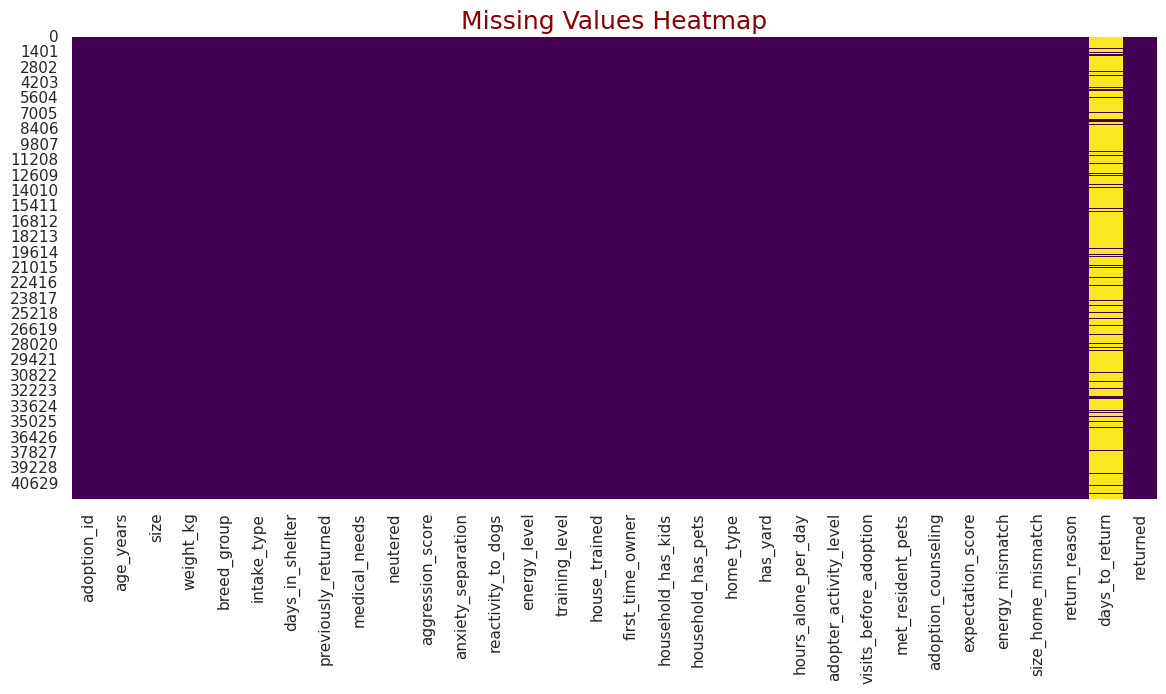

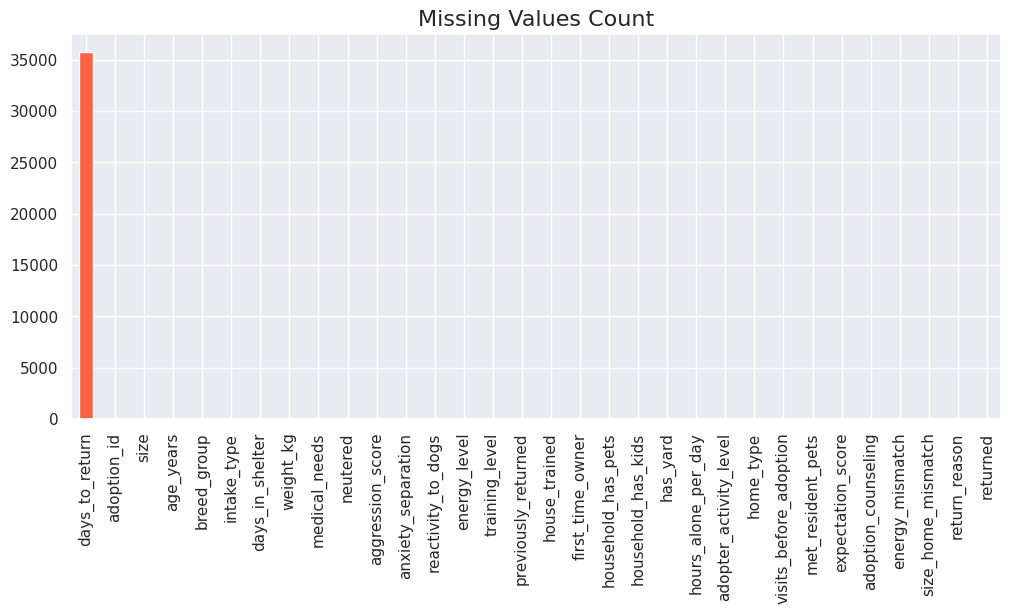

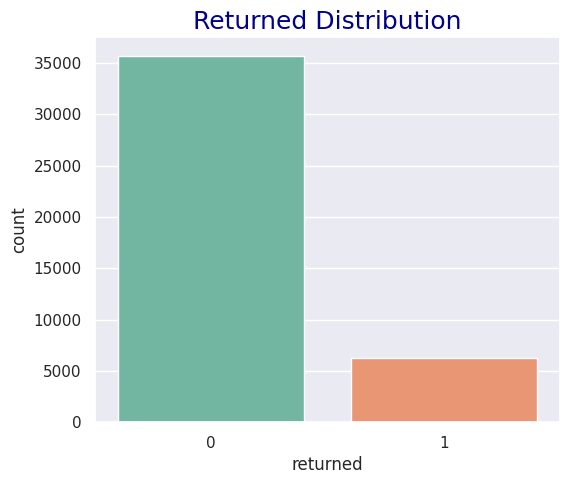

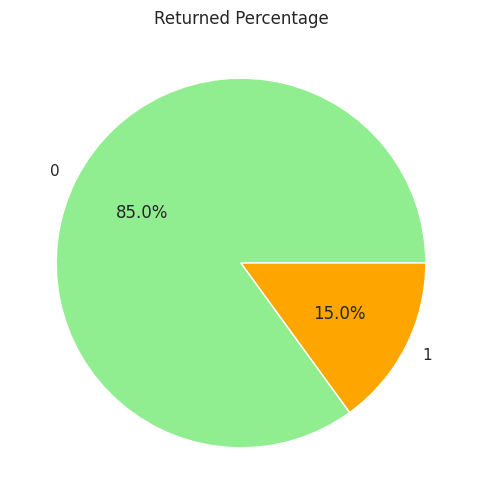

Index(['age_years', 'weight_kg', 'days_in_shelter', 'previously_returned',
       'neutered', 'aggression_score', 'anxiety_separation',
       'reactivity_to_dogs', 'energy_level', 'training_level', 'house_trained',
       'first_time_owner', 'household_has_kids', 'household_has_pets',
       'has_yard', 'hours_alone_per_day', 'adopter_activity_level',
       'visits_before_adoption', 'met_resident_pets', 'adoption_counseling',
       'expectation_score', 'energy_mismatch', 'size_home_mismatch',
       'days_to_return', 'returned'],
      dtype='object')


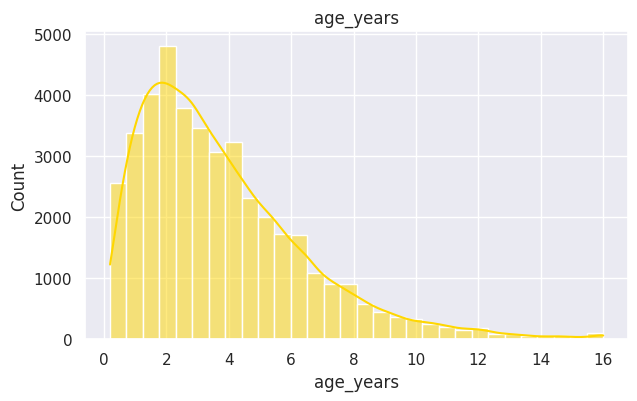

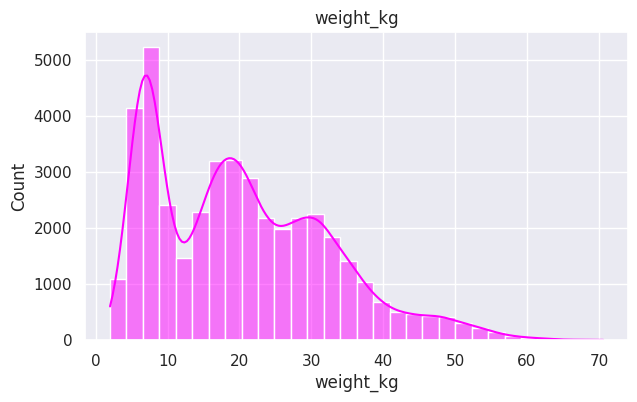

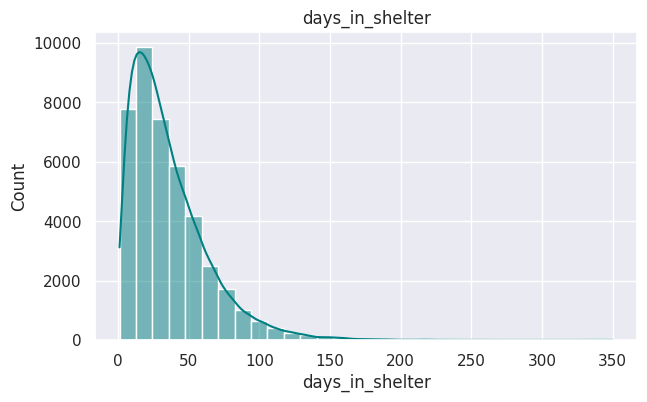

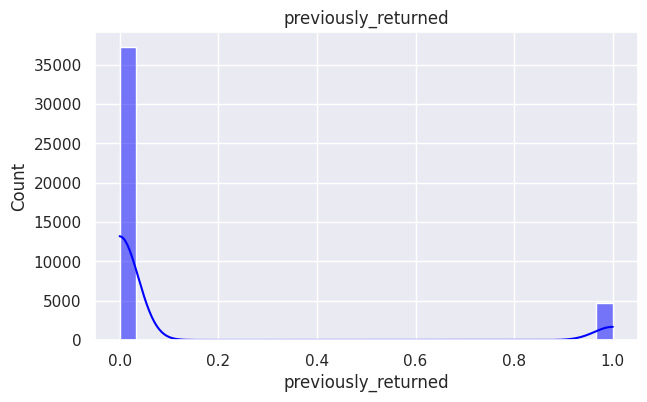

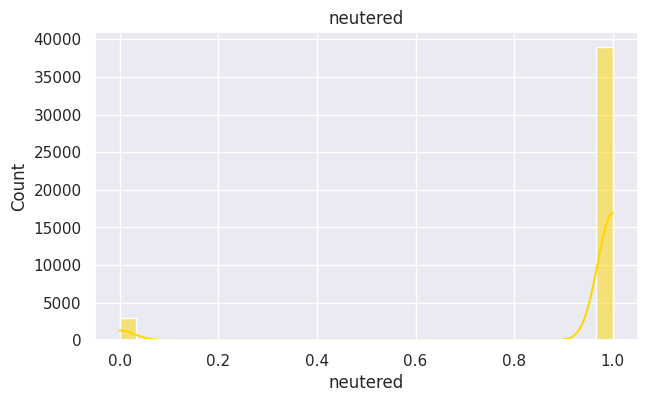

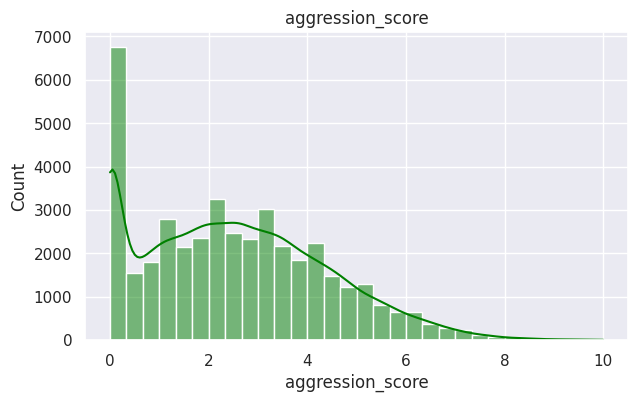

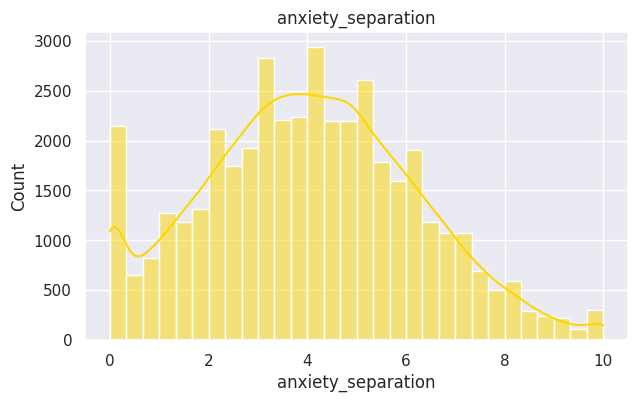

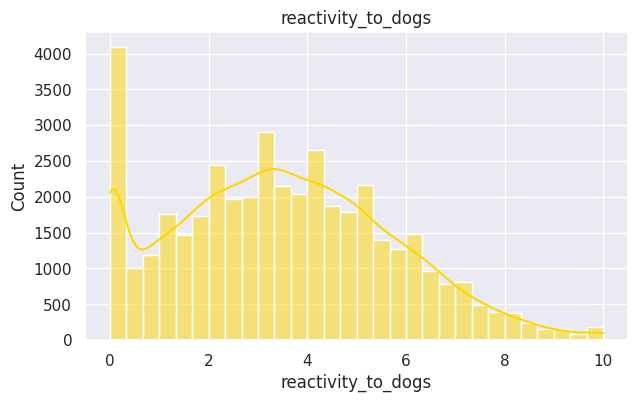

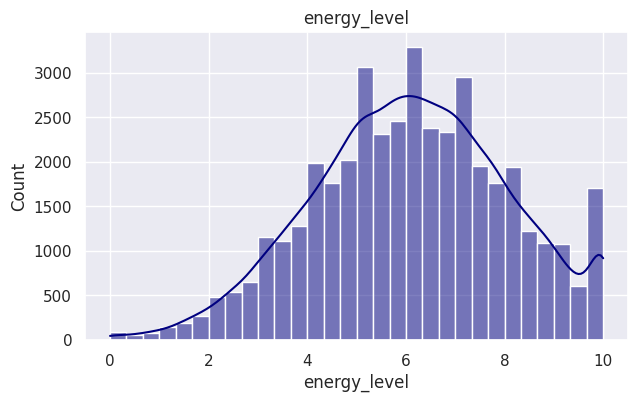

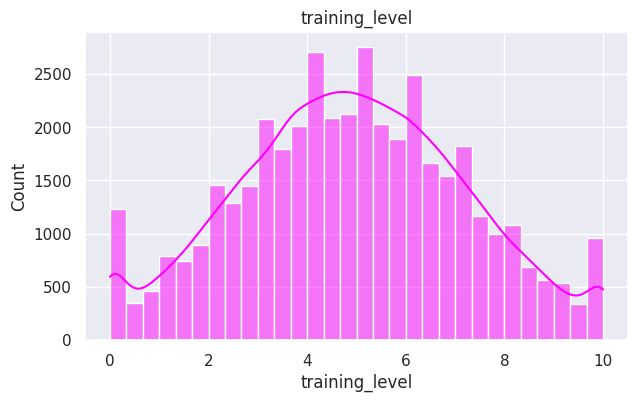

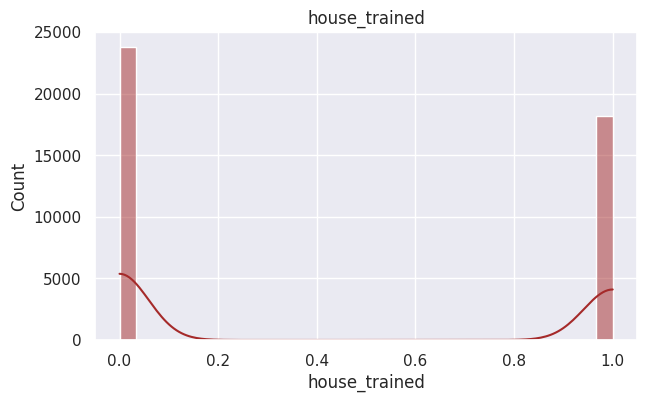

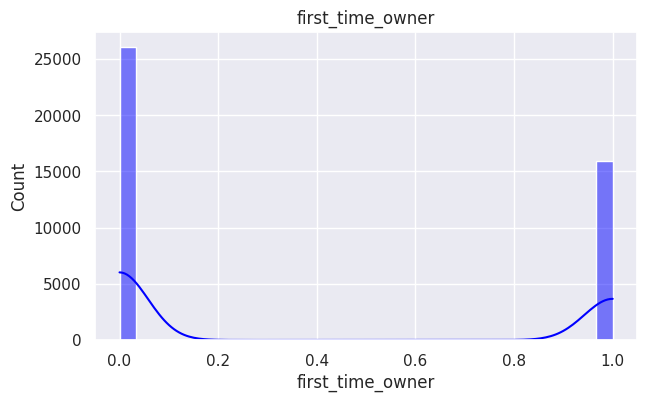

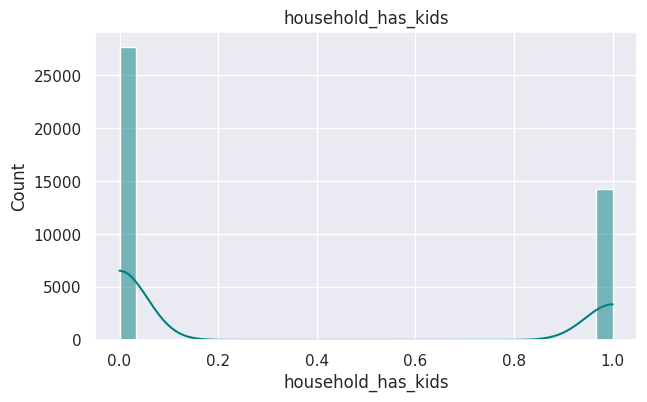

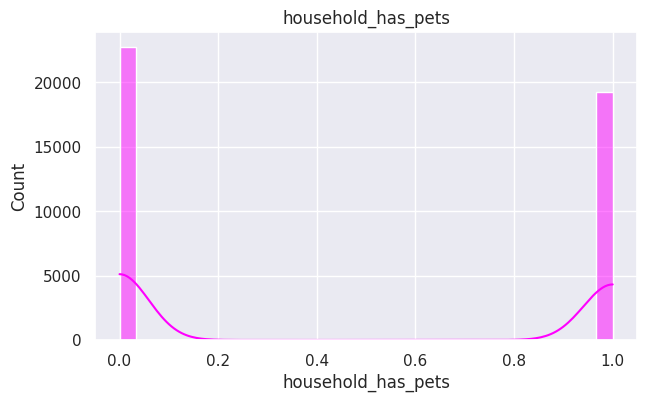

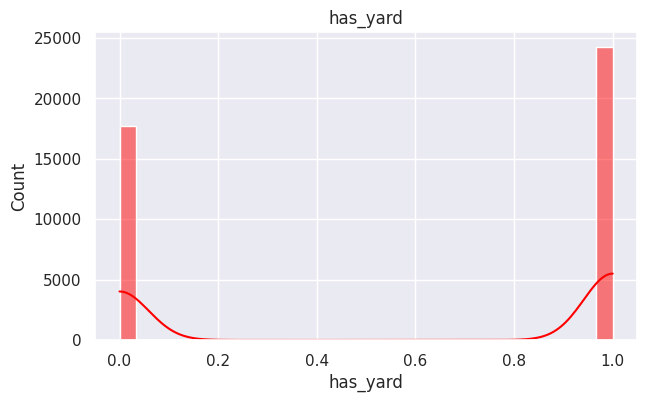

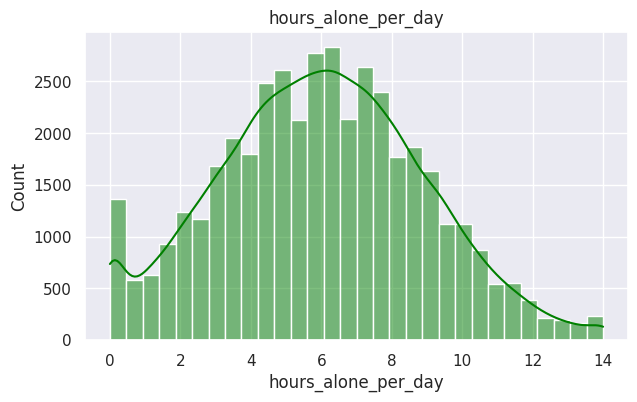

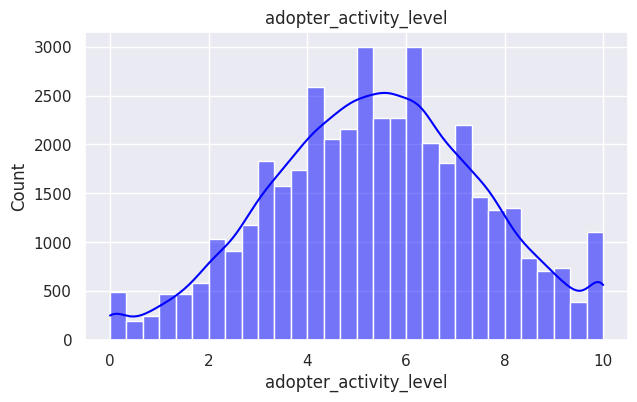

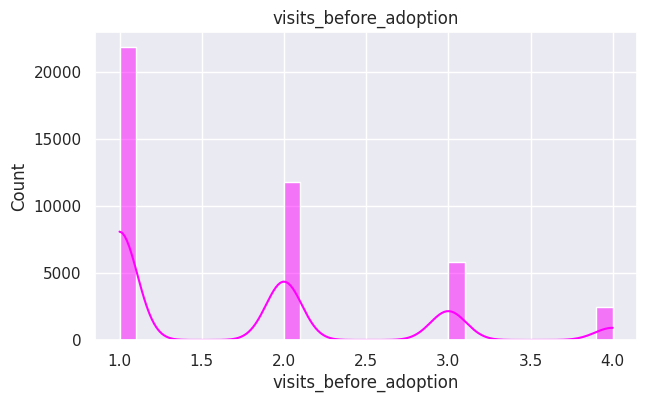

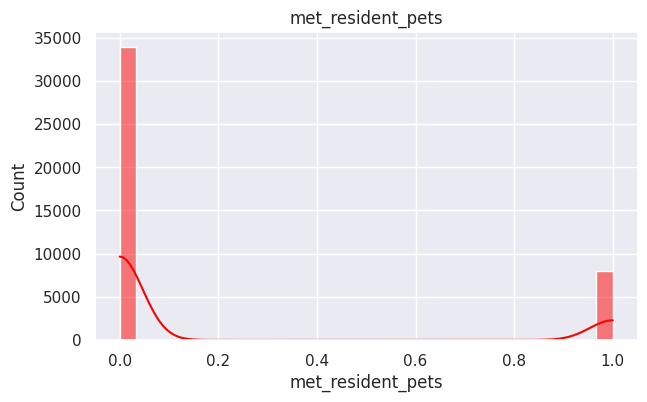

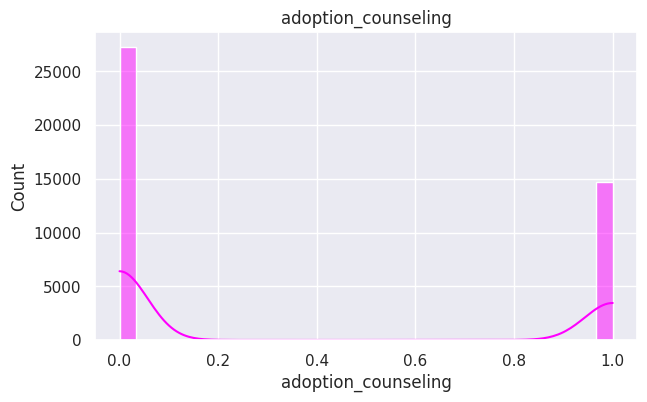

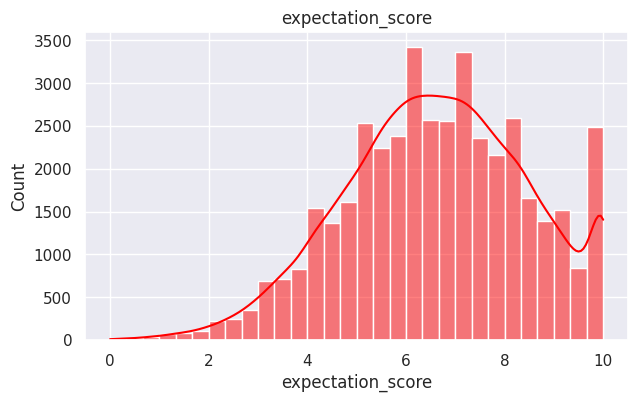

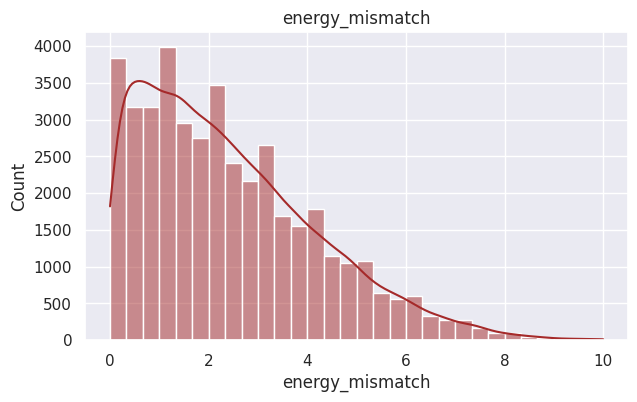

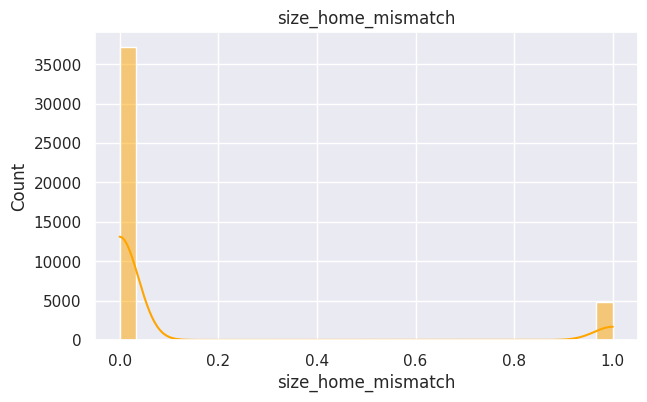

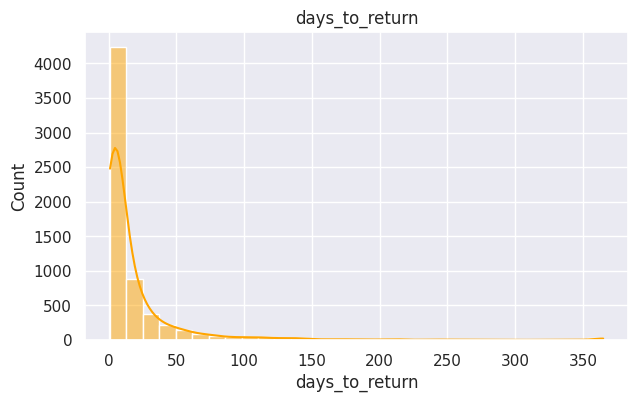

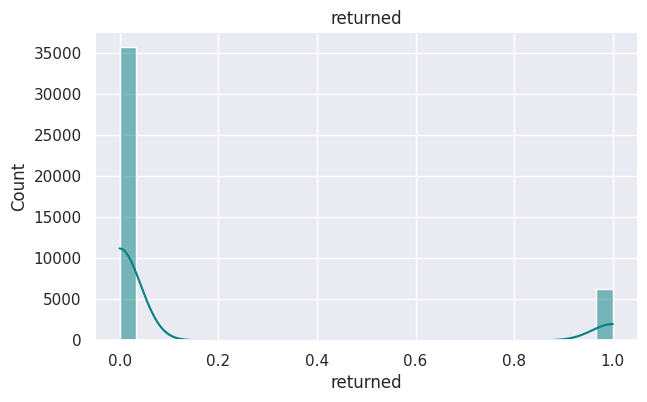

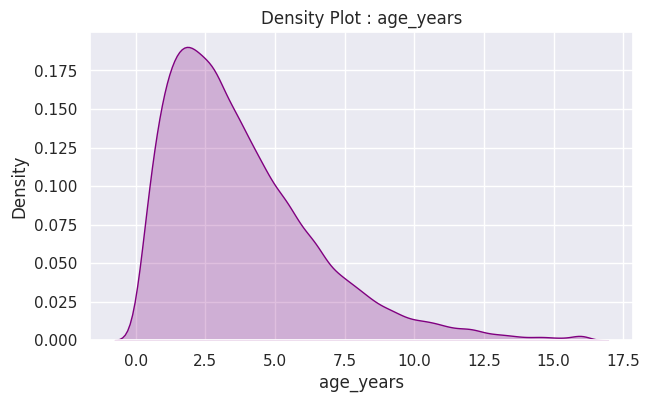

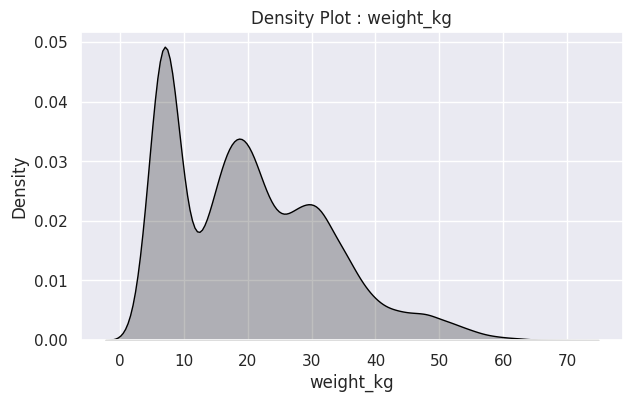

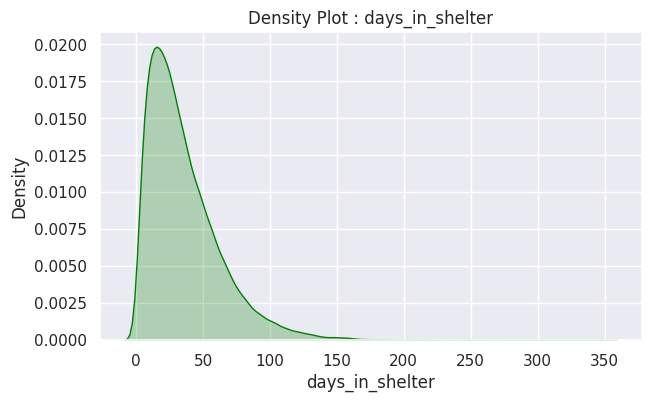

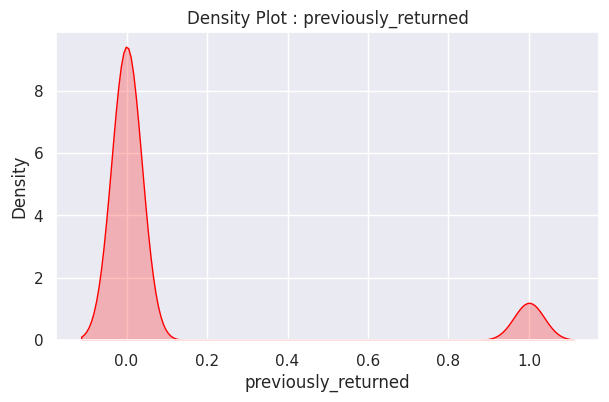

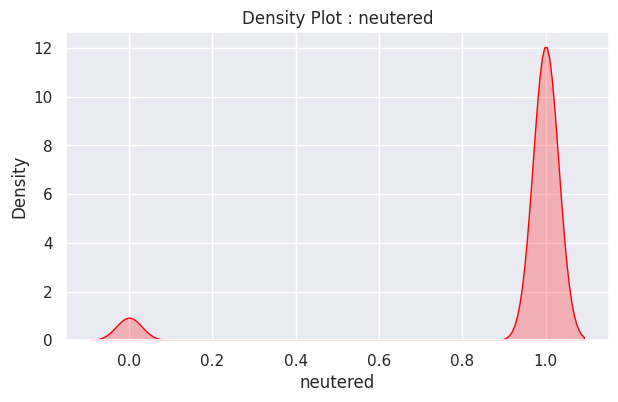

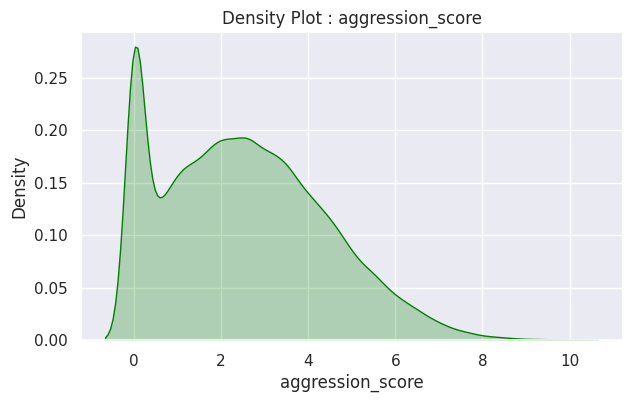

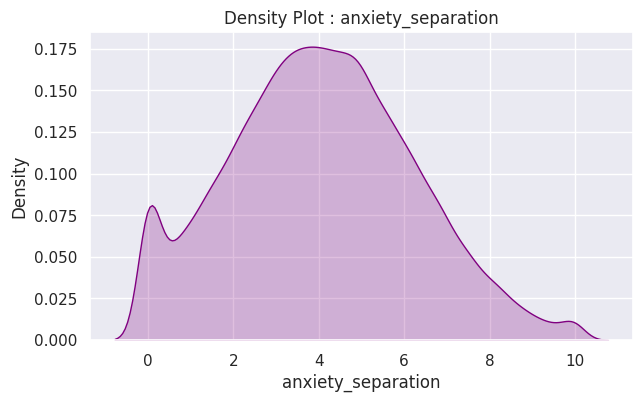

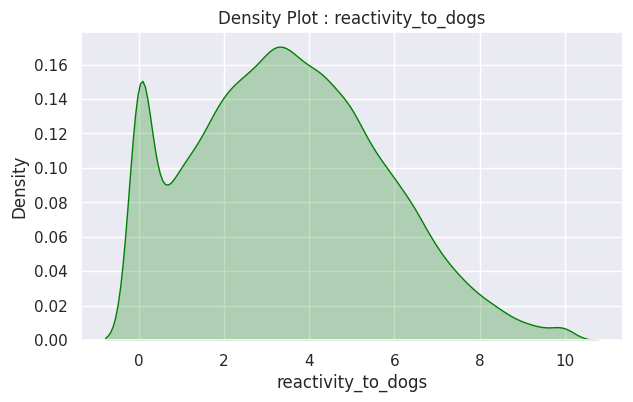

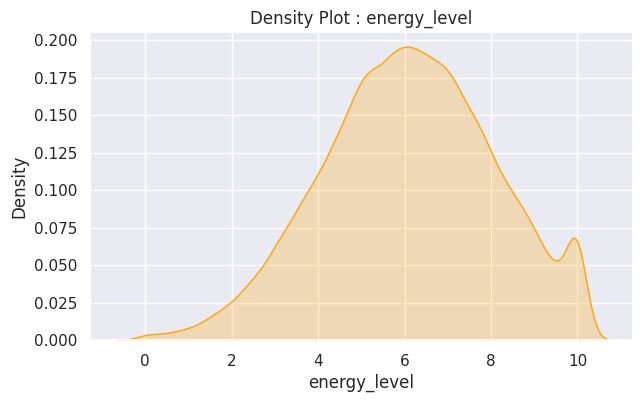

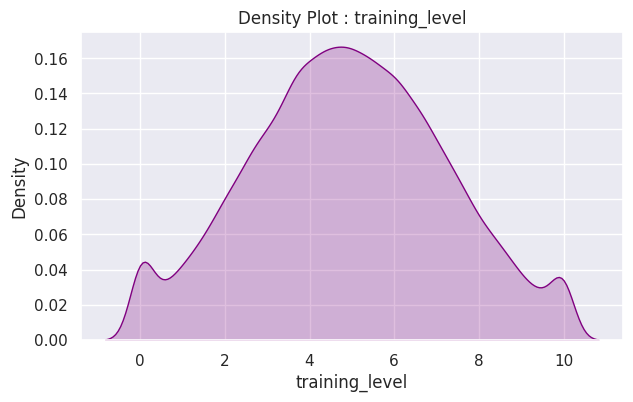

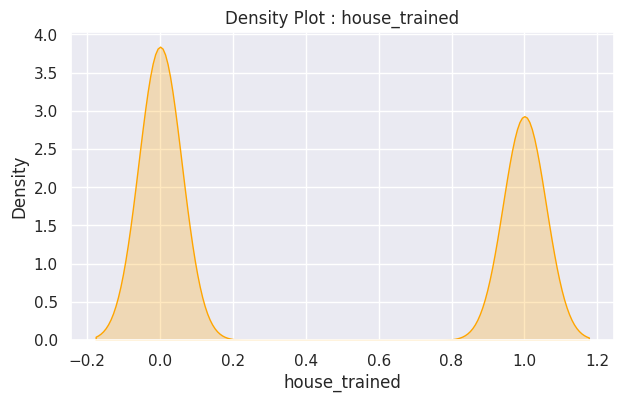

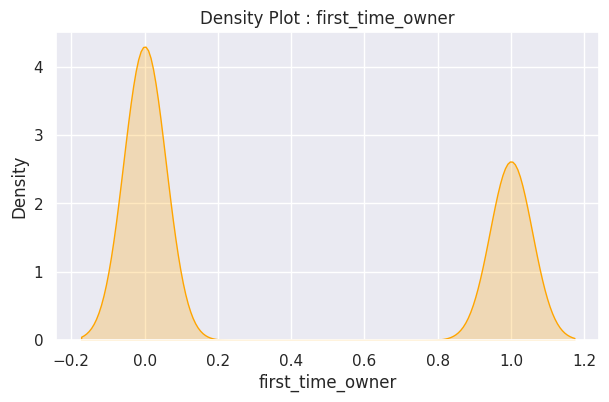

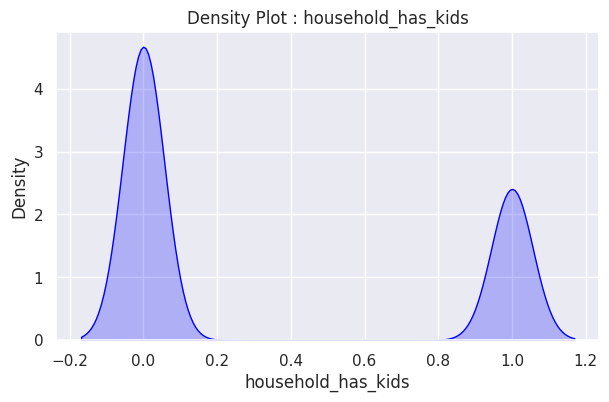

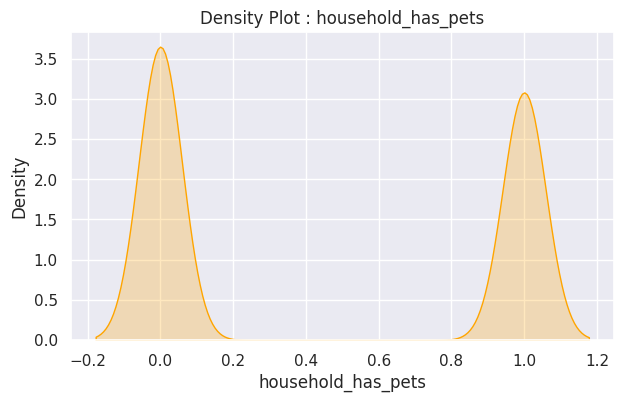

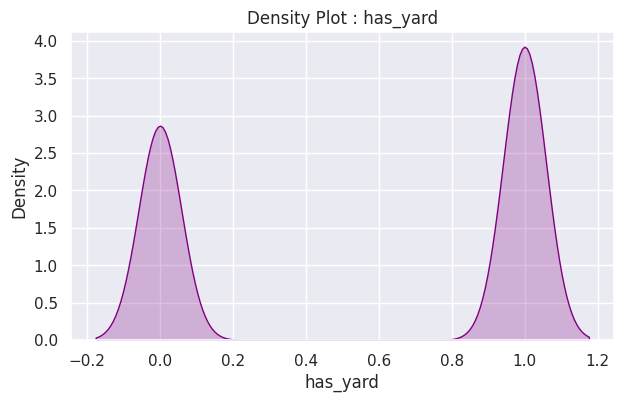

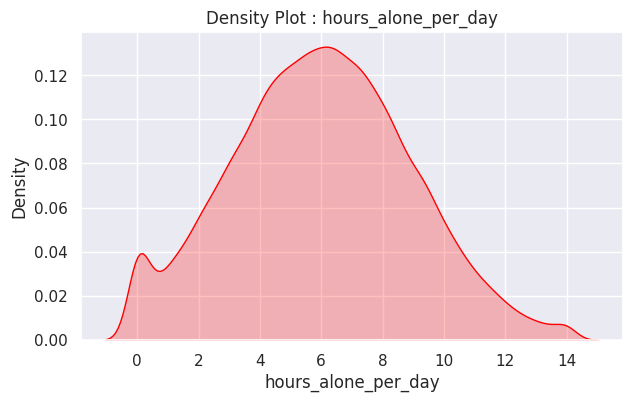

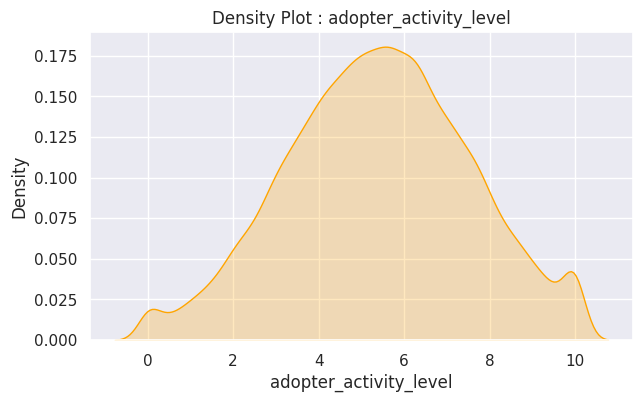

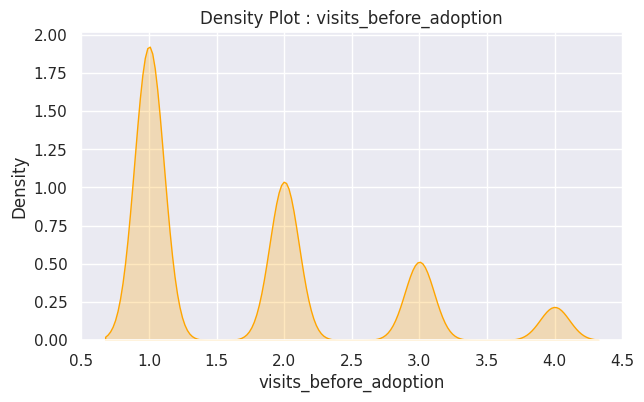

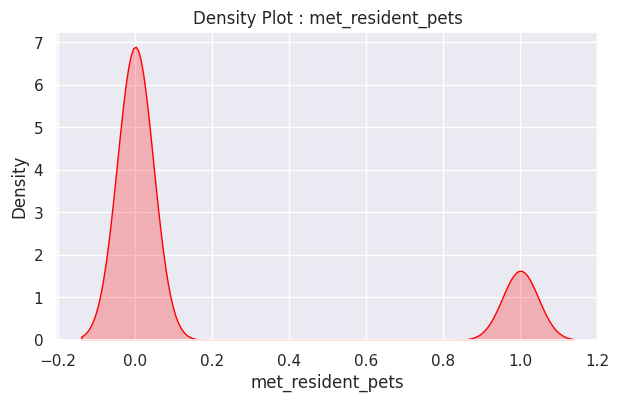

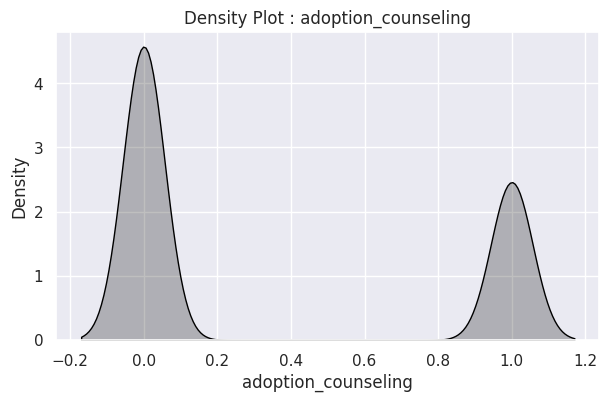

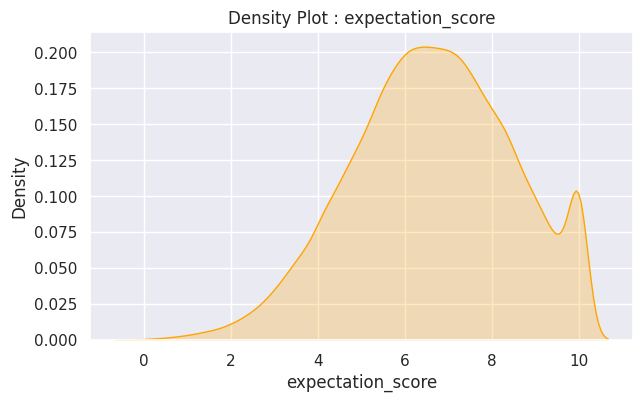

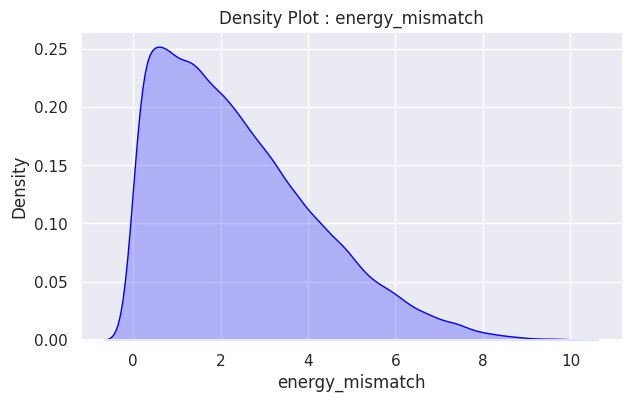

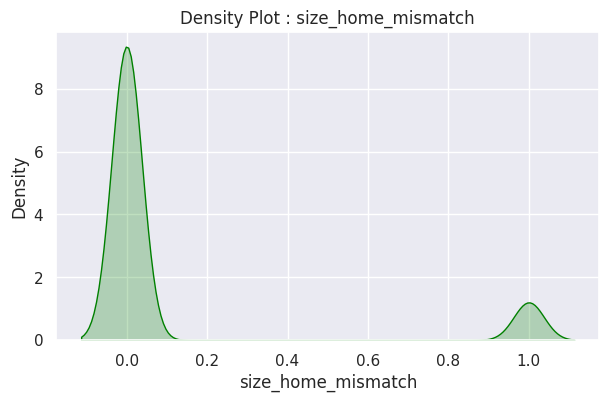

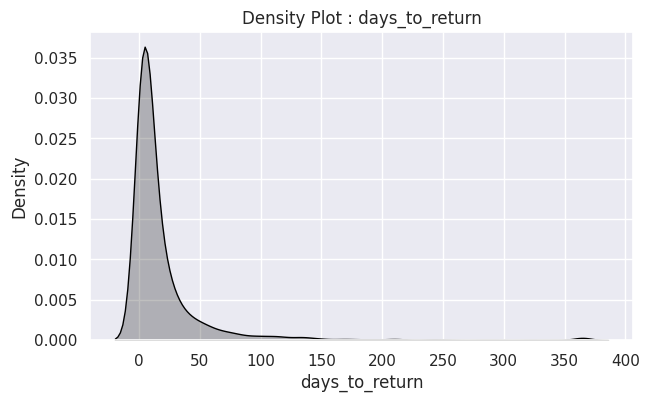

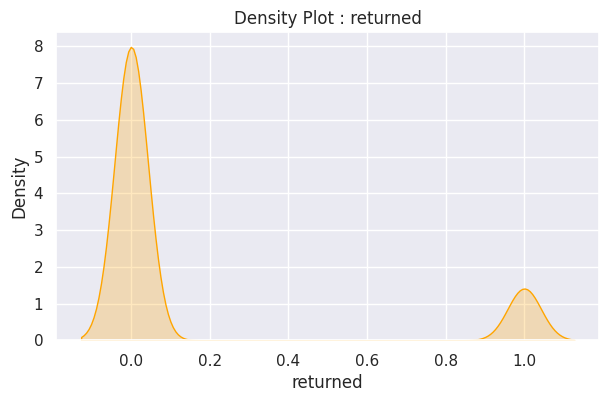

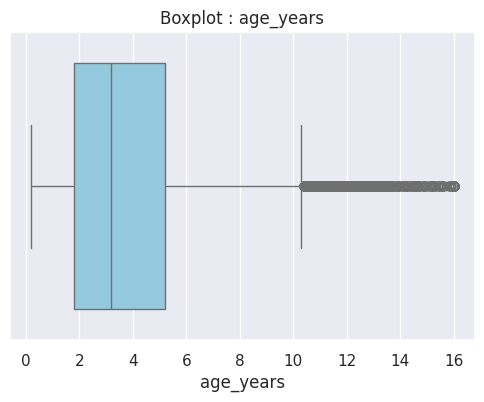

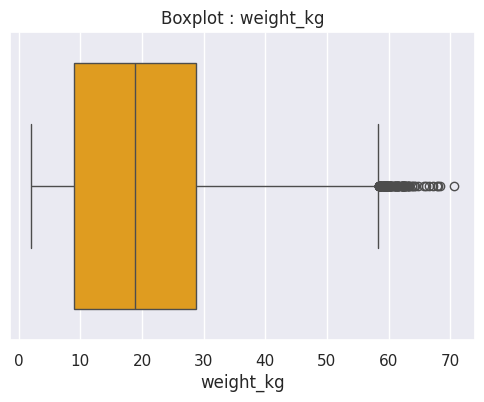

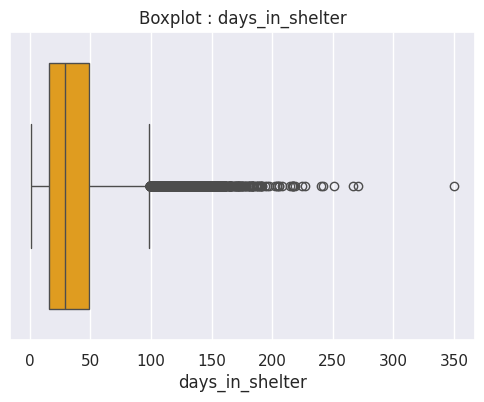

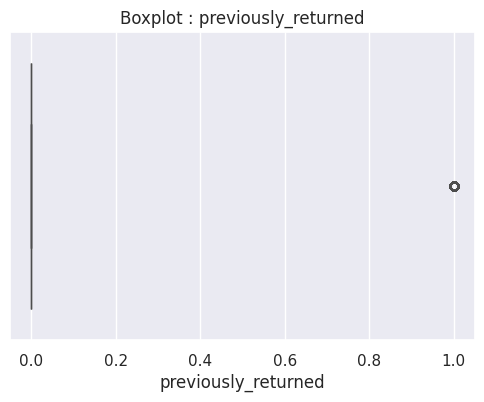

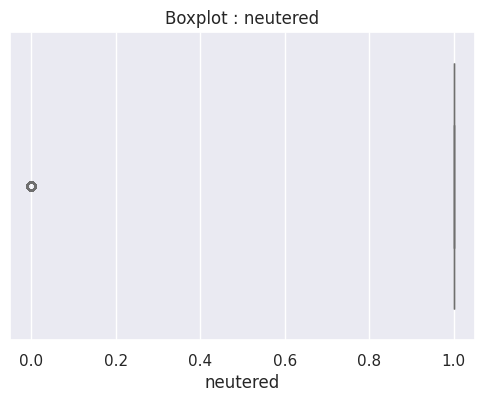

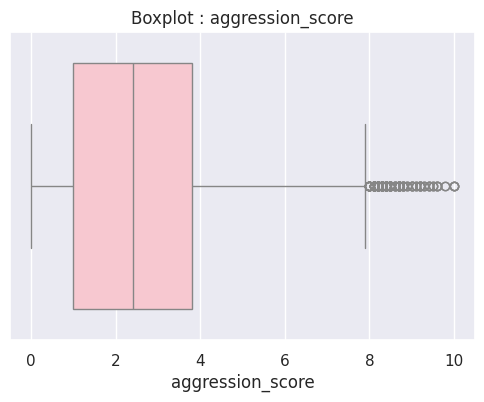

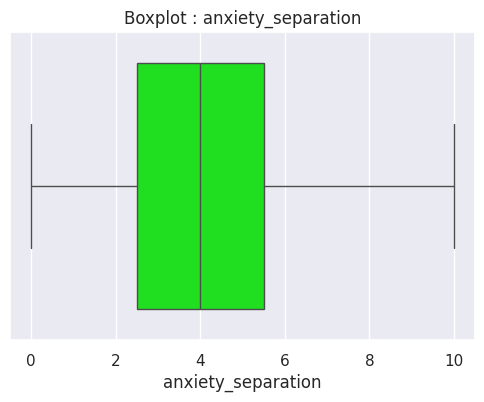

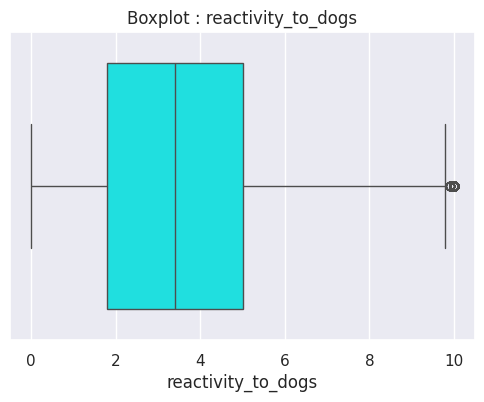

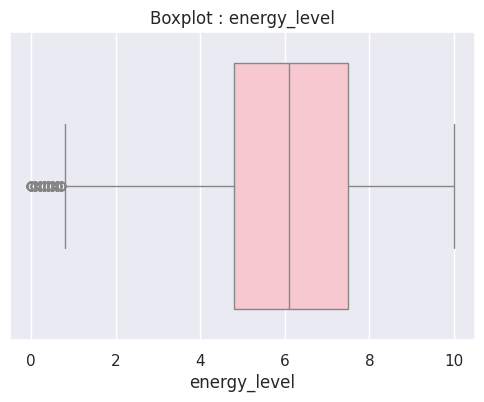

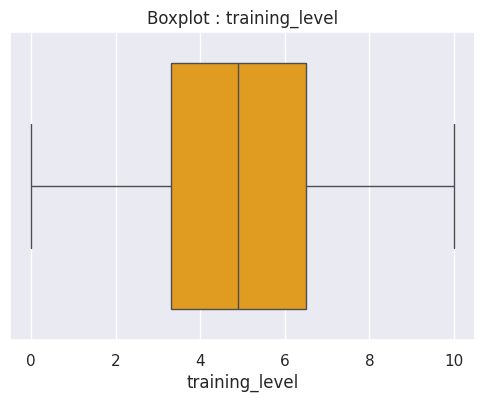

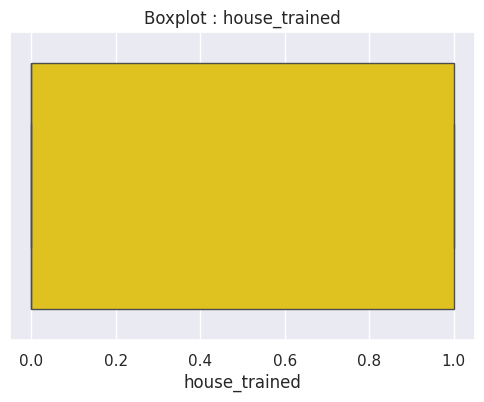

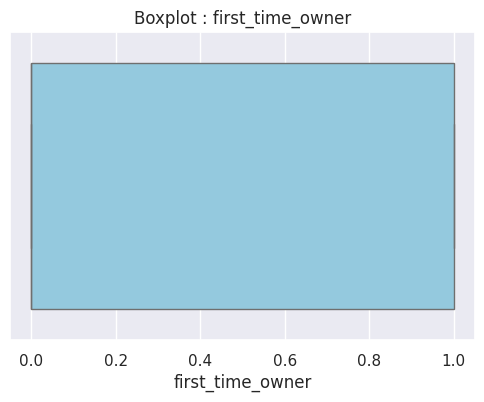

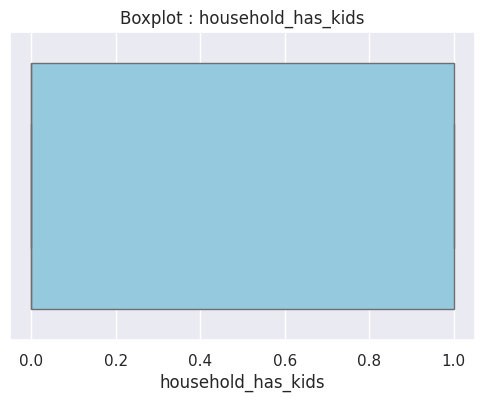

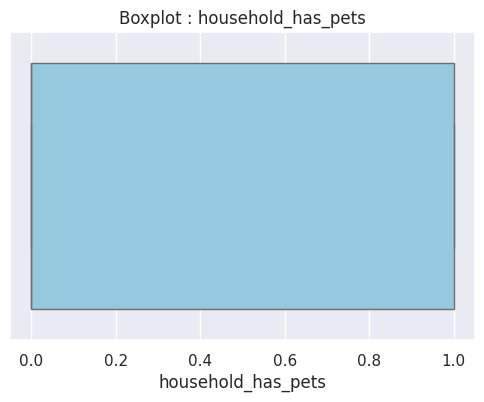

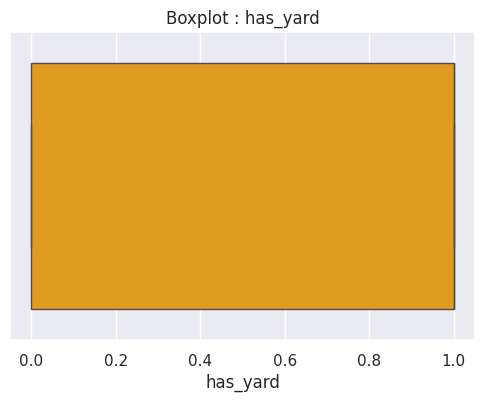

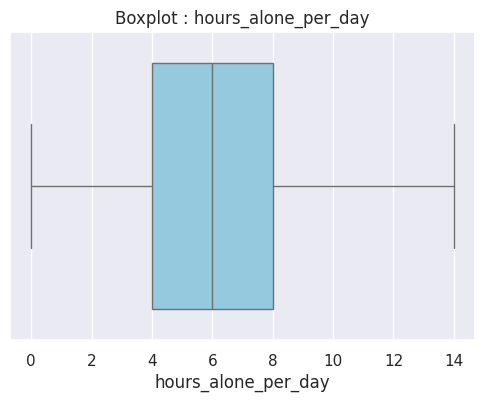

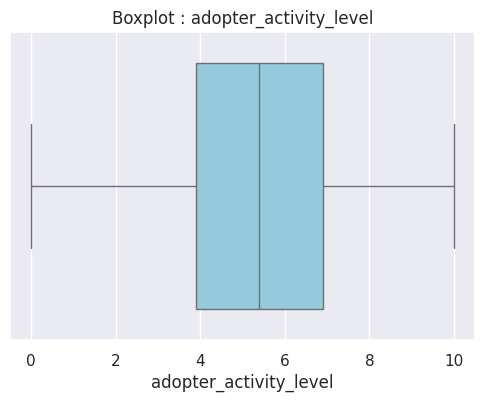

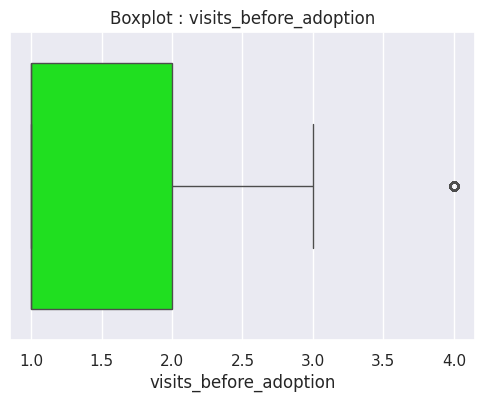

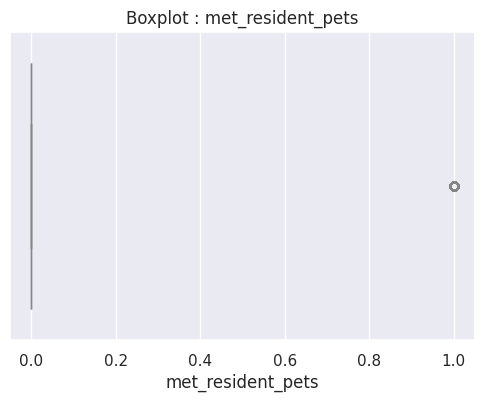

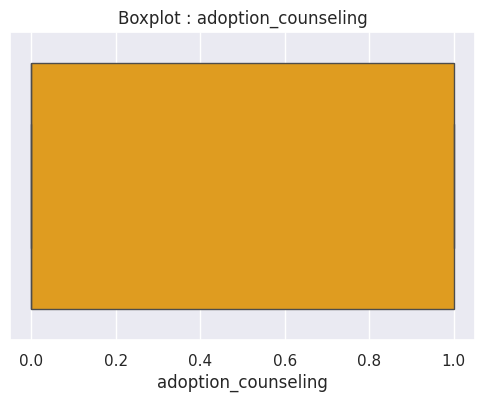

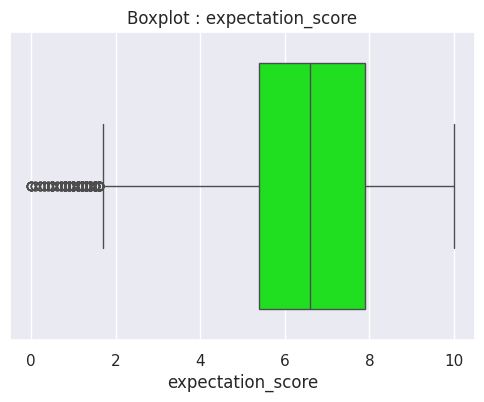

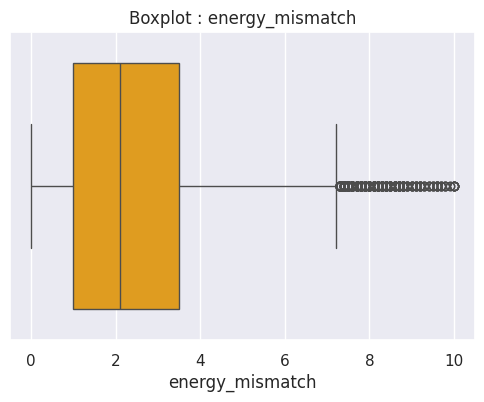

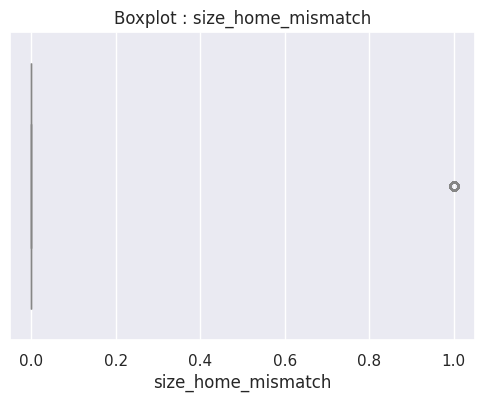

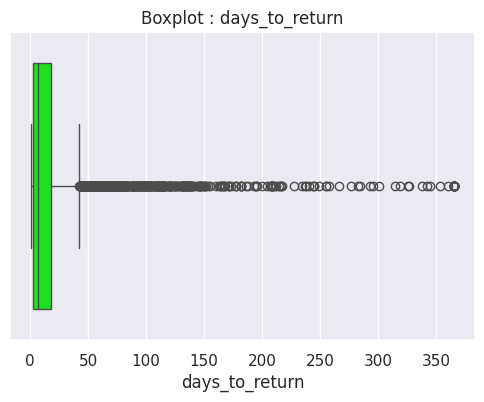

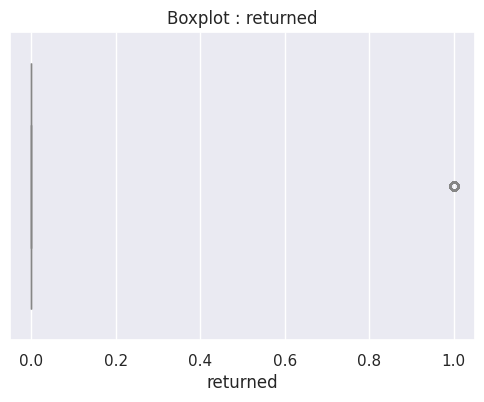

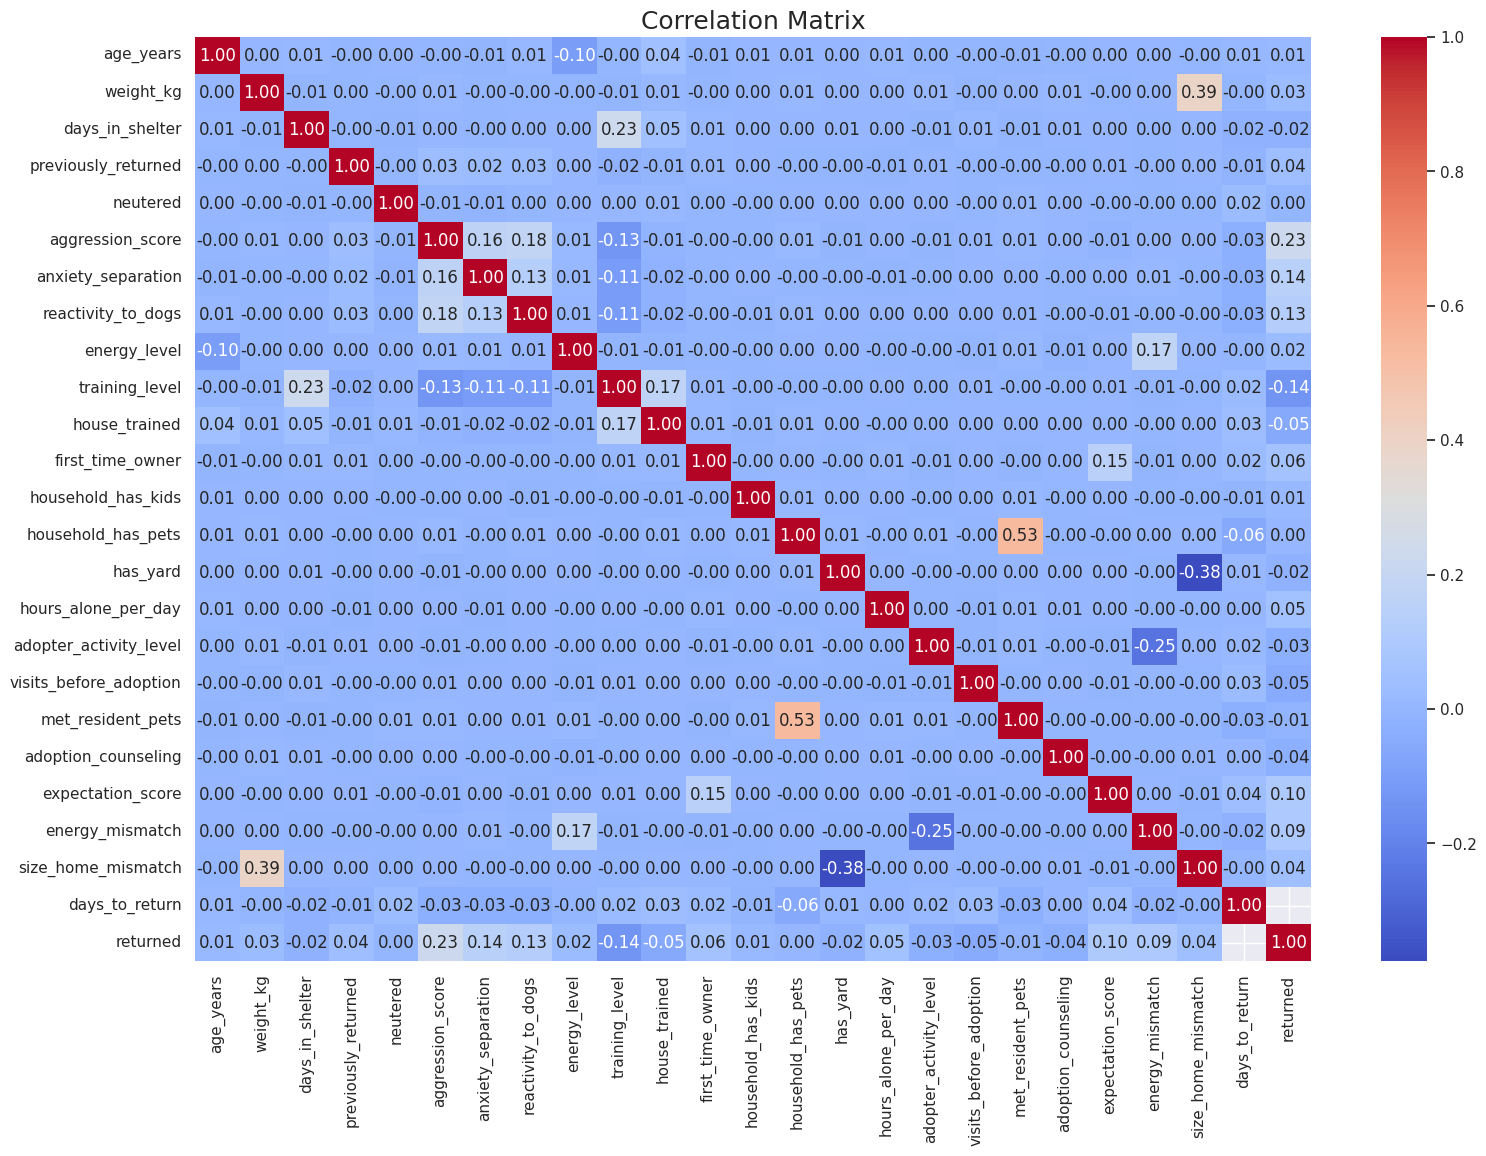

Index(['adoption_id', 'size', 'breed_group', 'intake_type', 'medical_needs',
       'home_type', 'return_reason'],
      dtype='object')


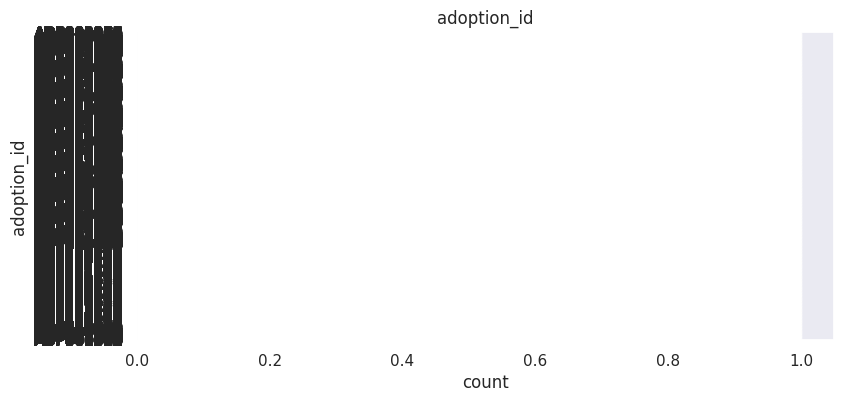

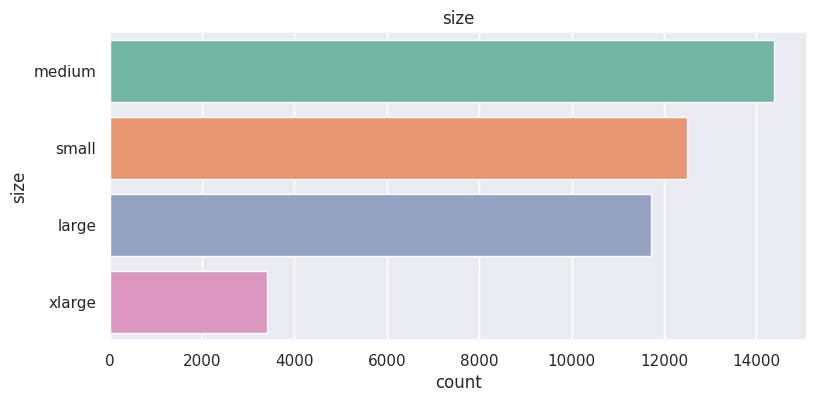

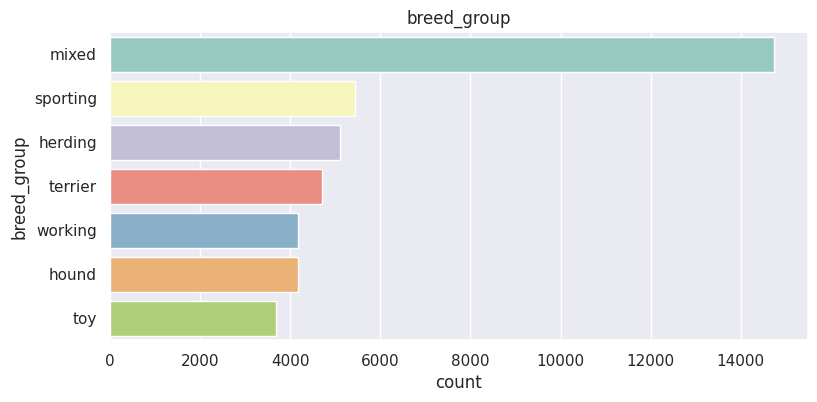

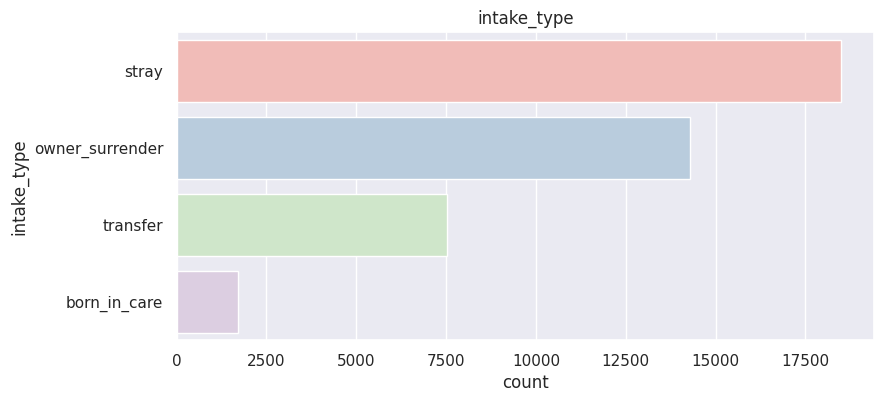

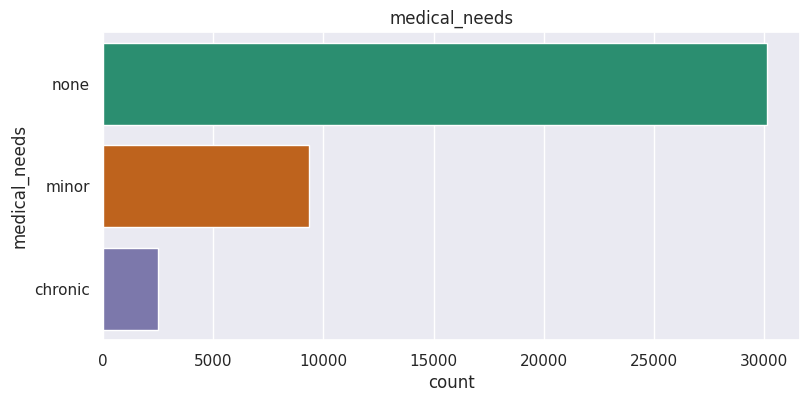

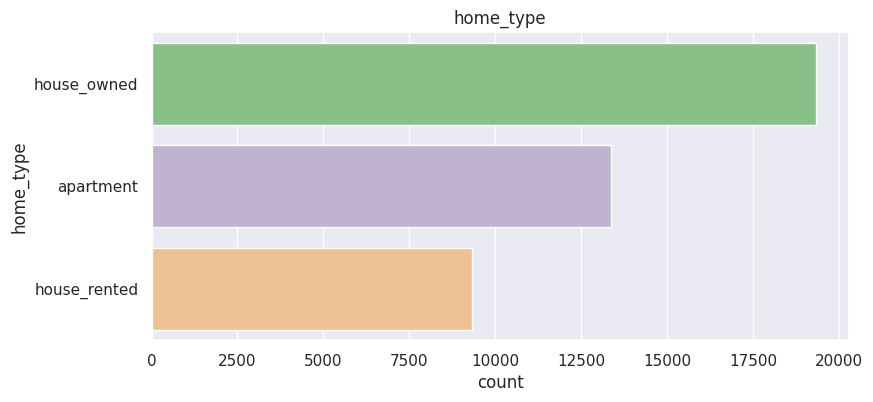

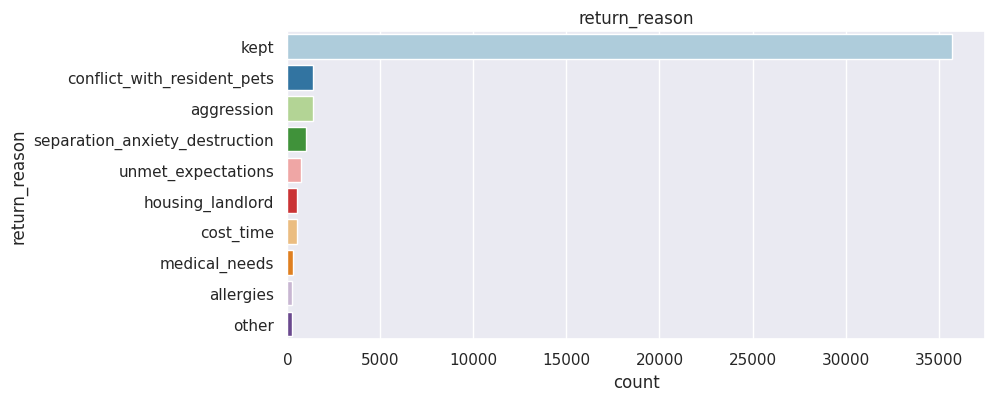

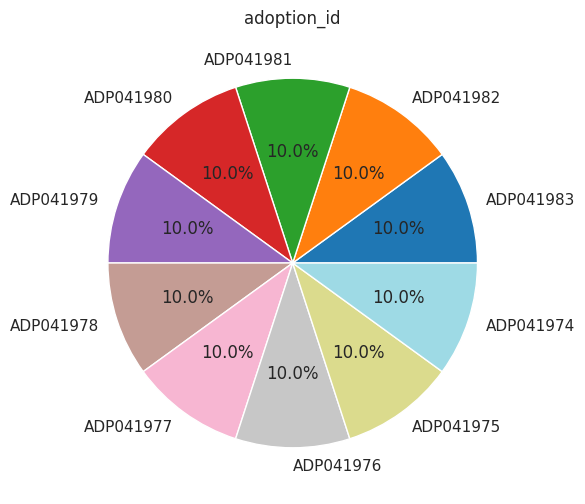

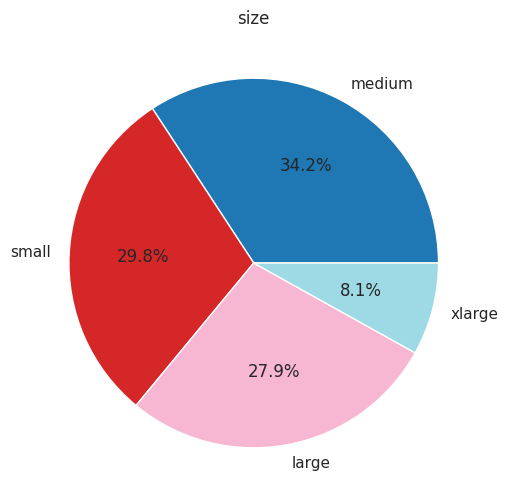

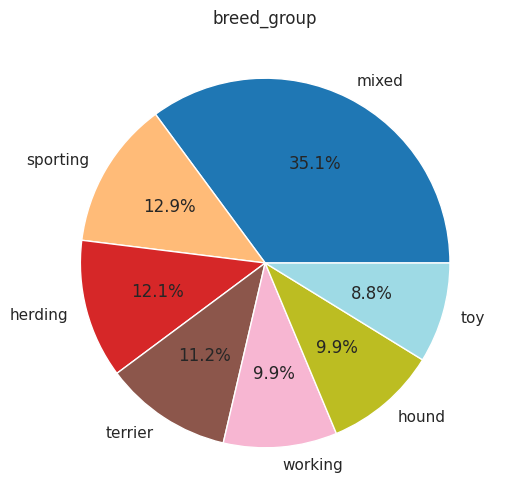

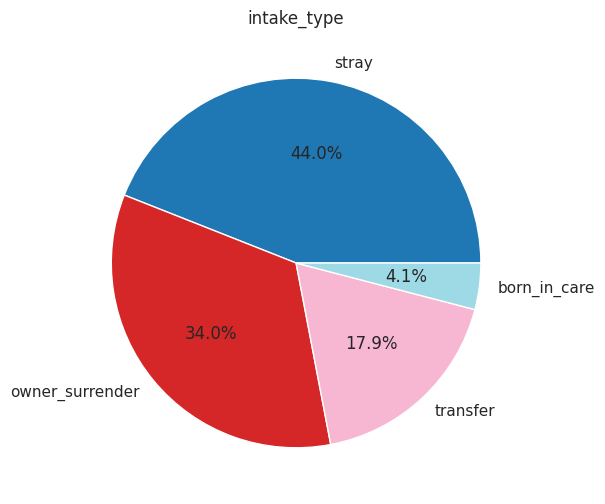

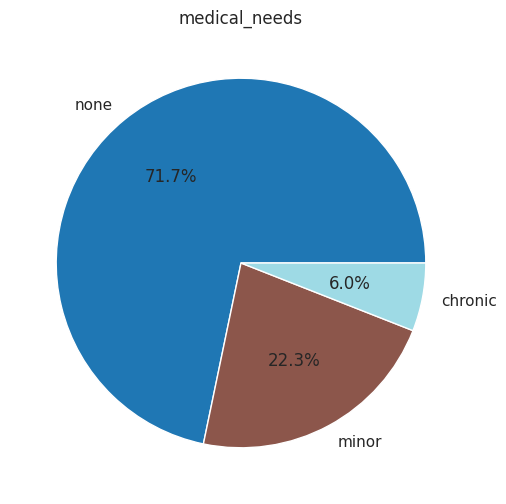

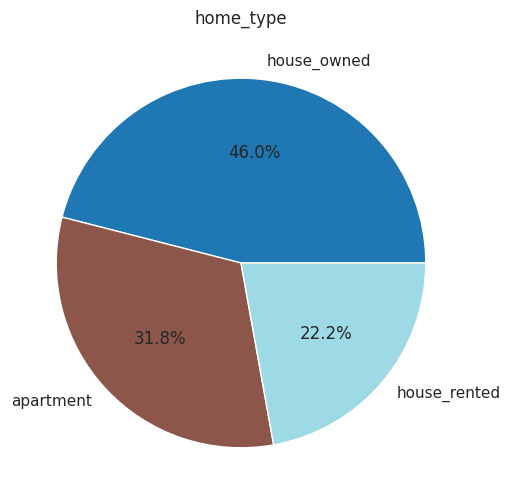

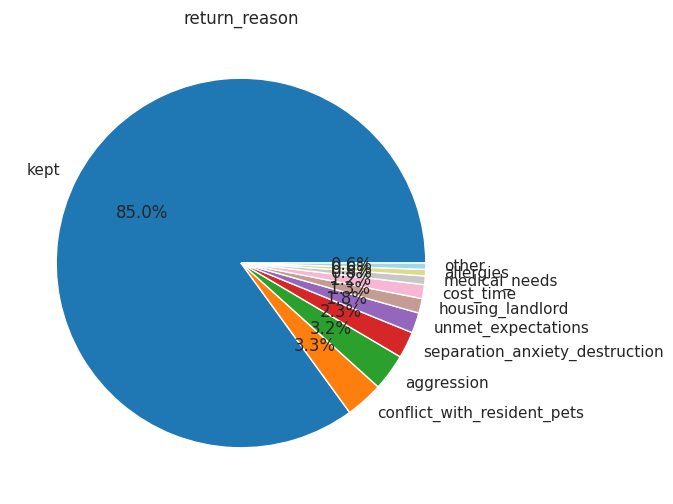

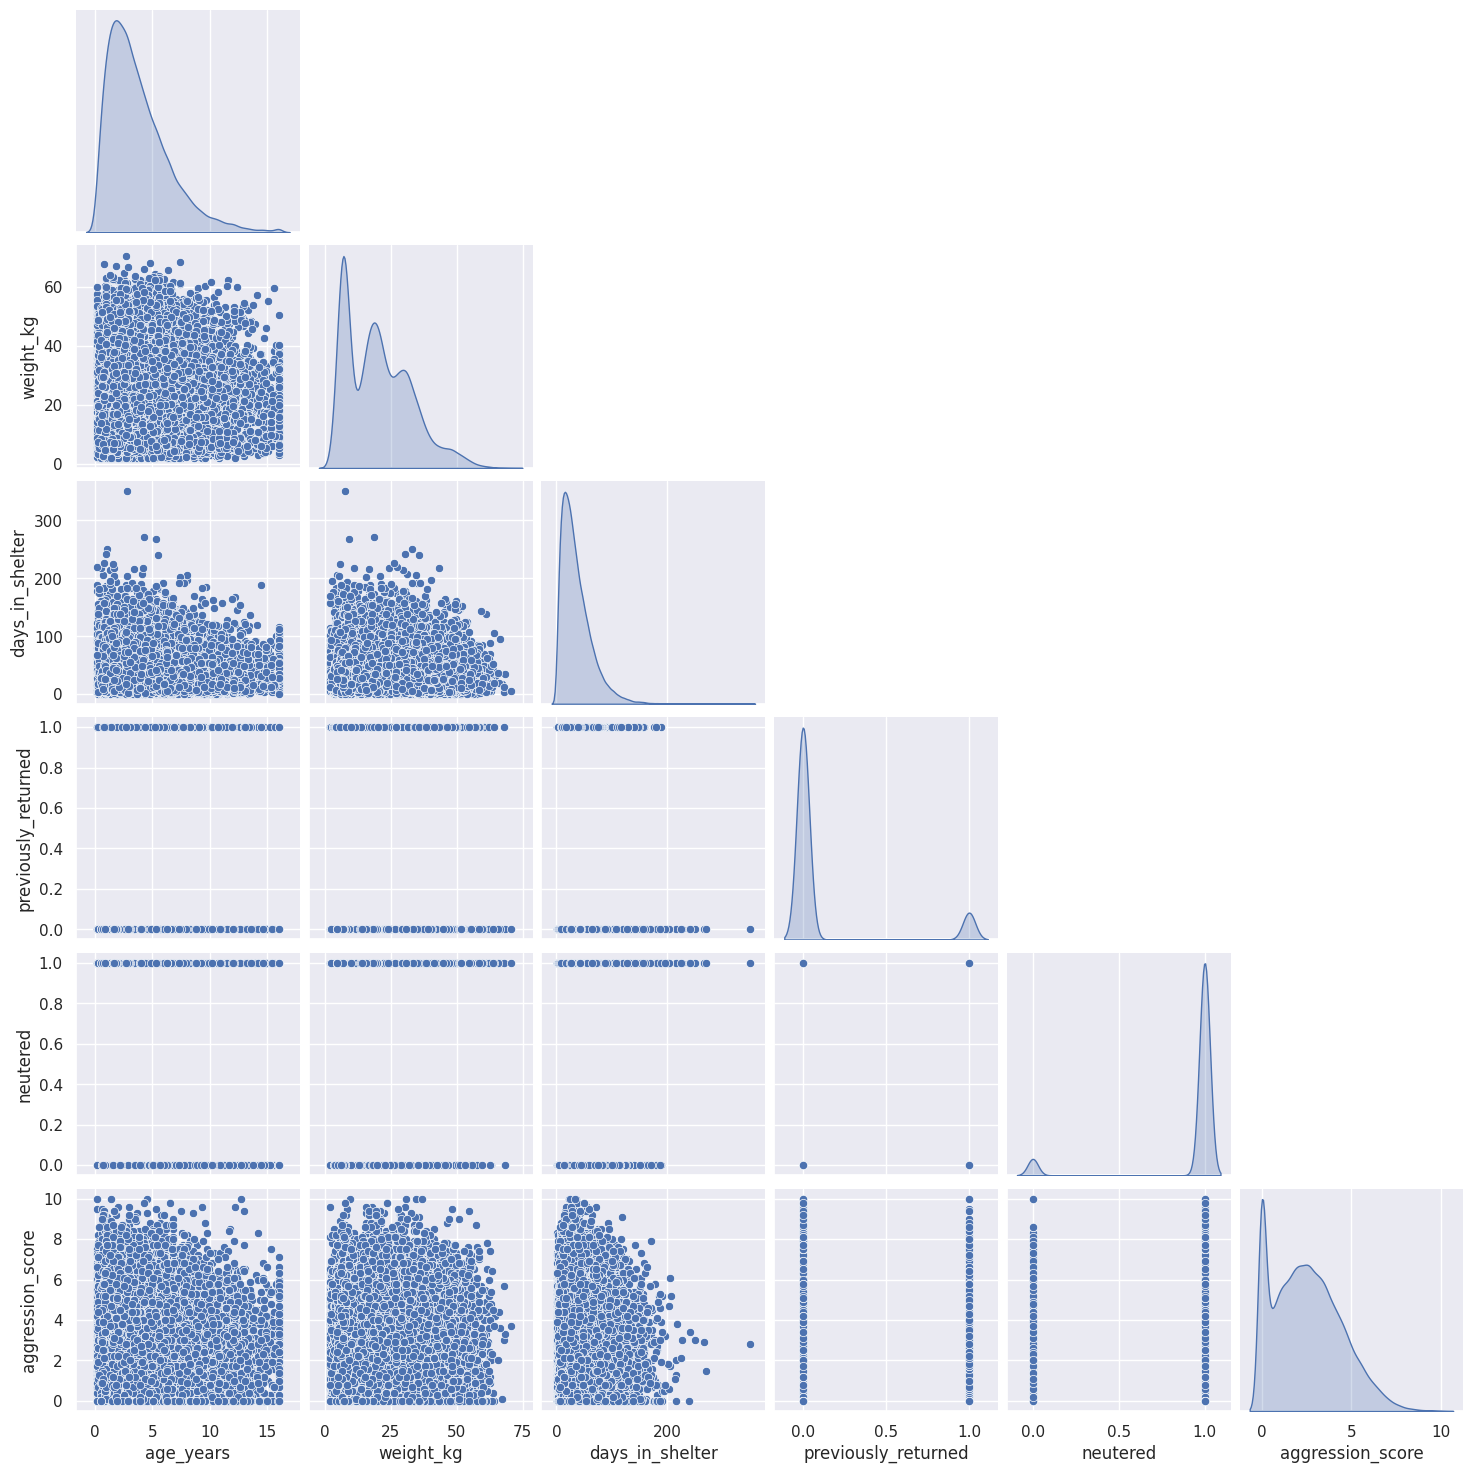

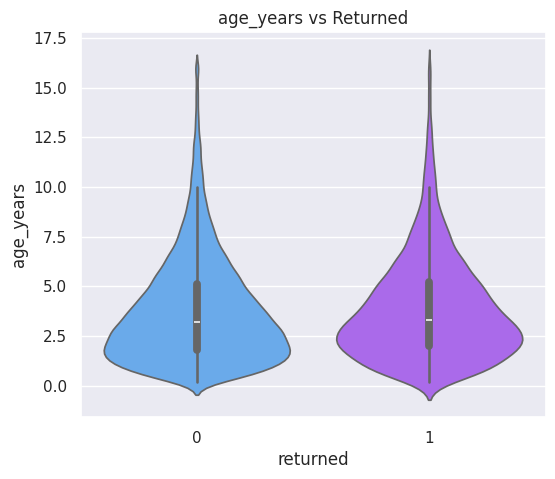

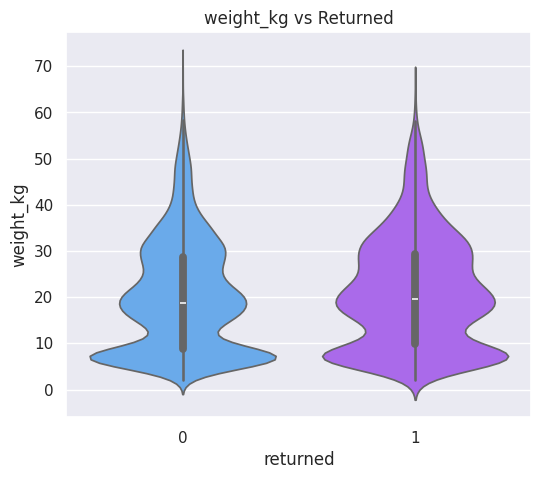

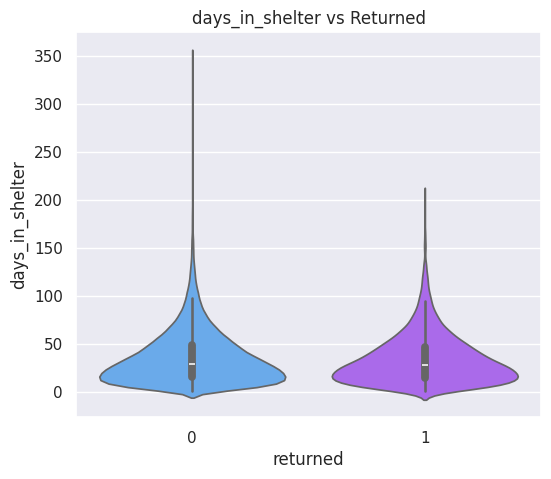

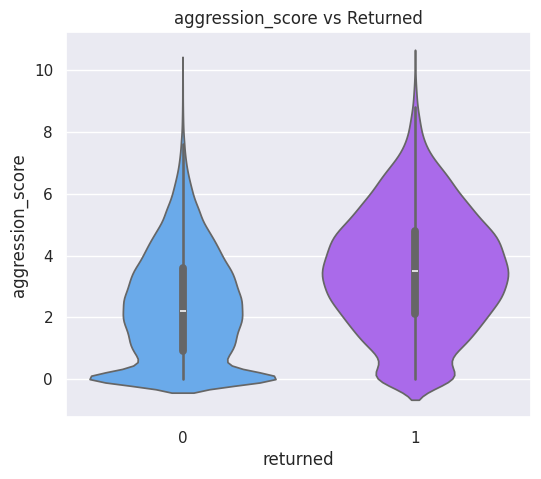

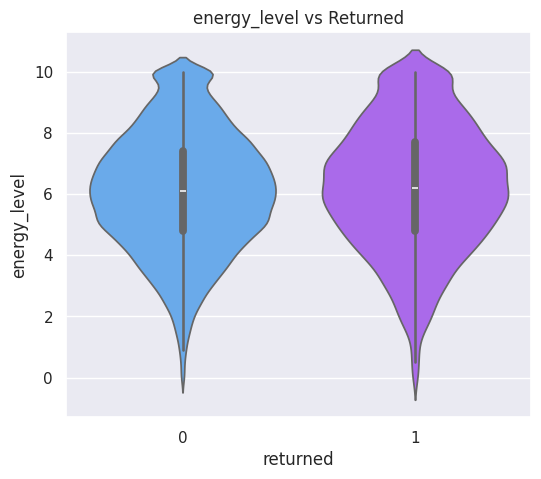

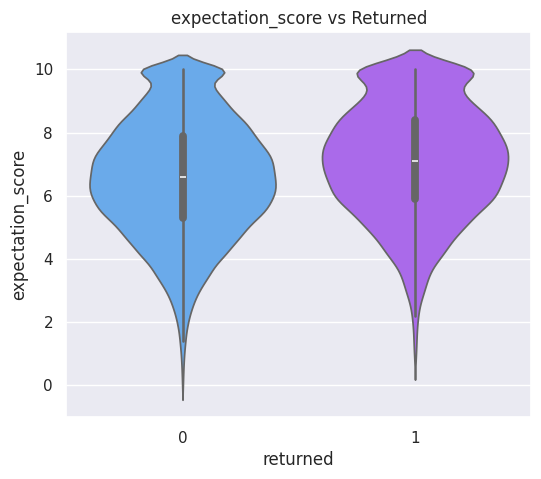

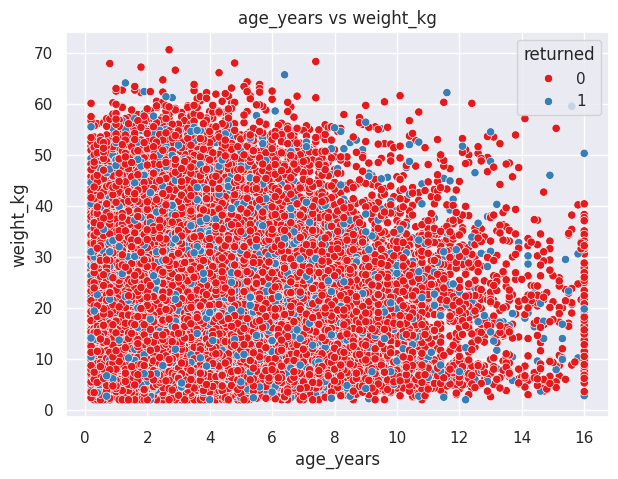

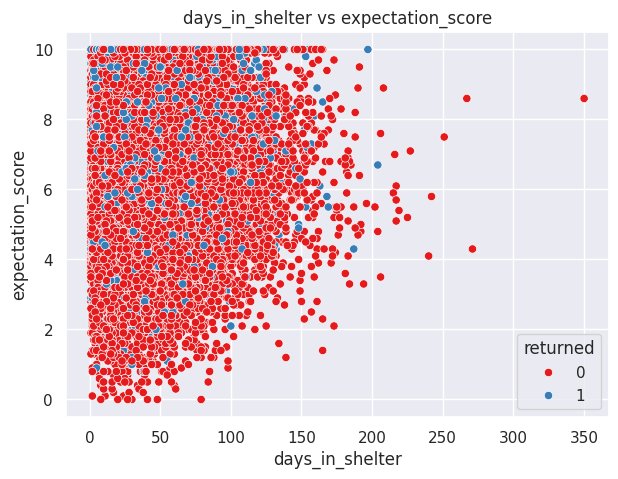

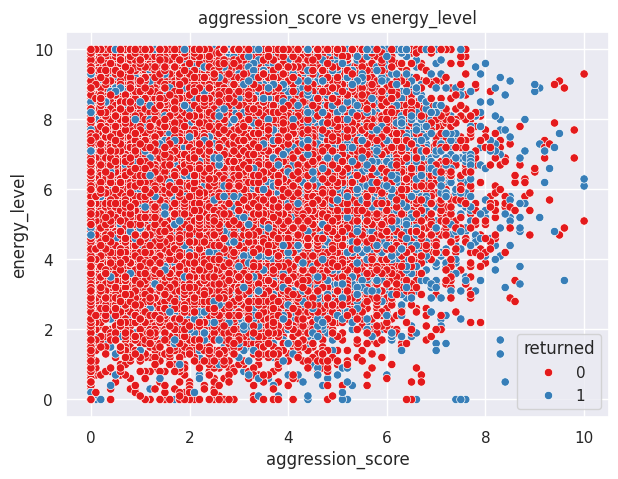

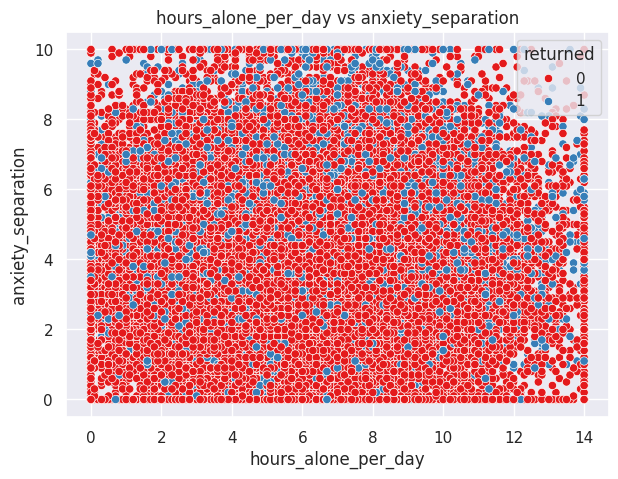

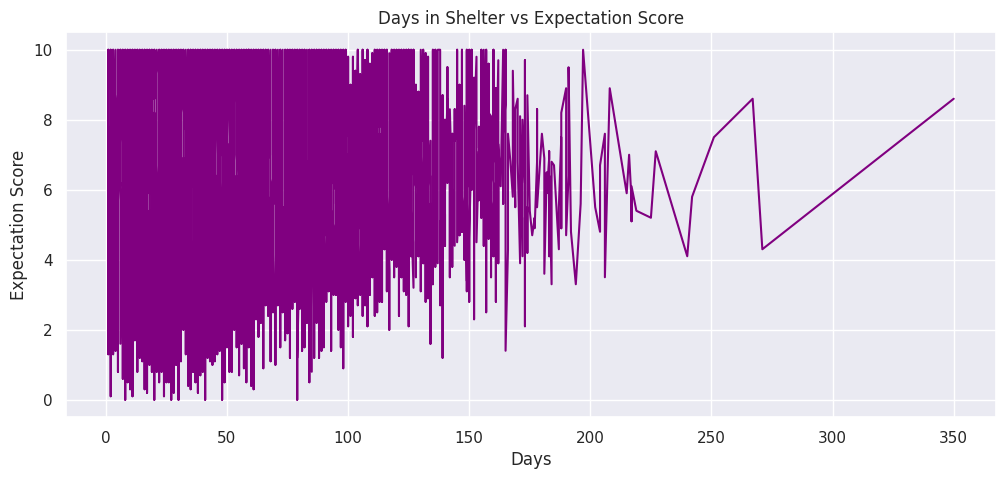

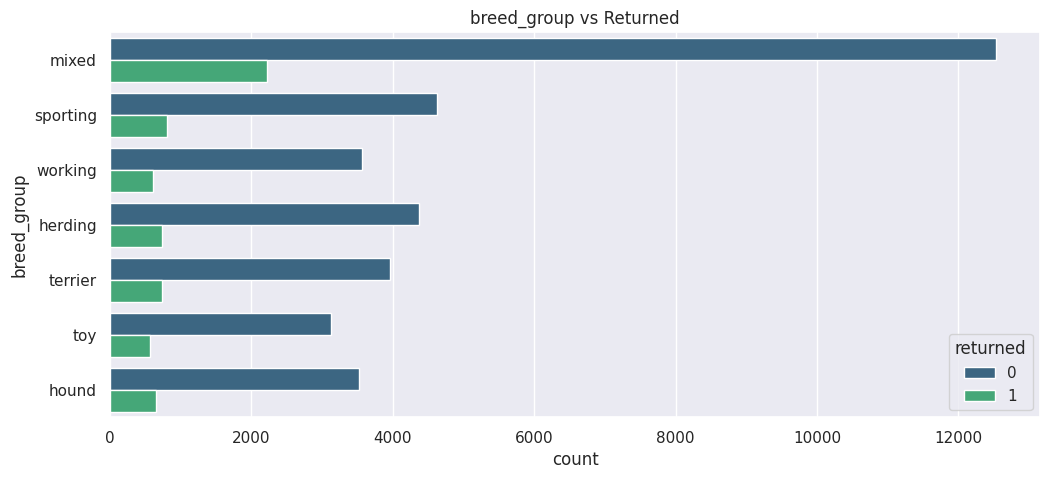

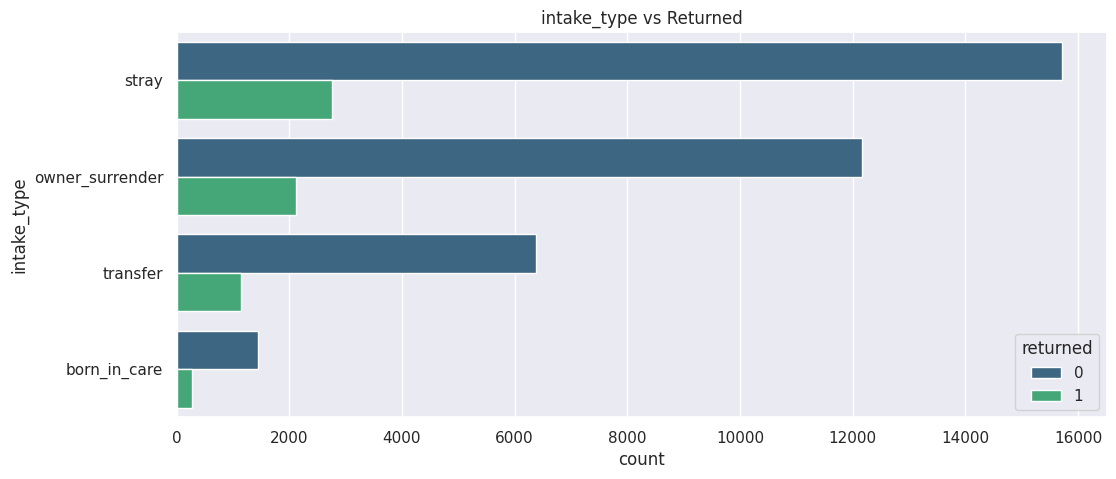

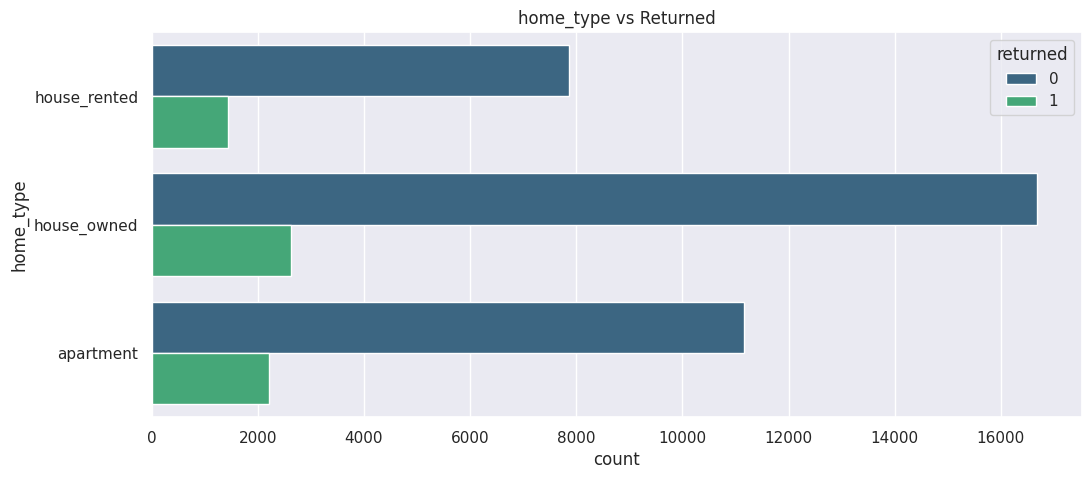

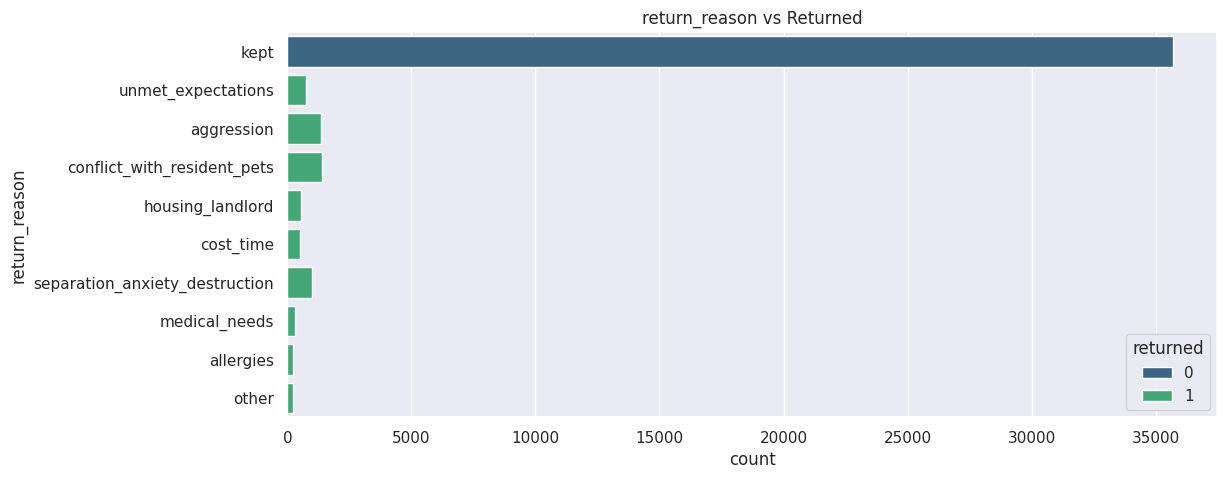

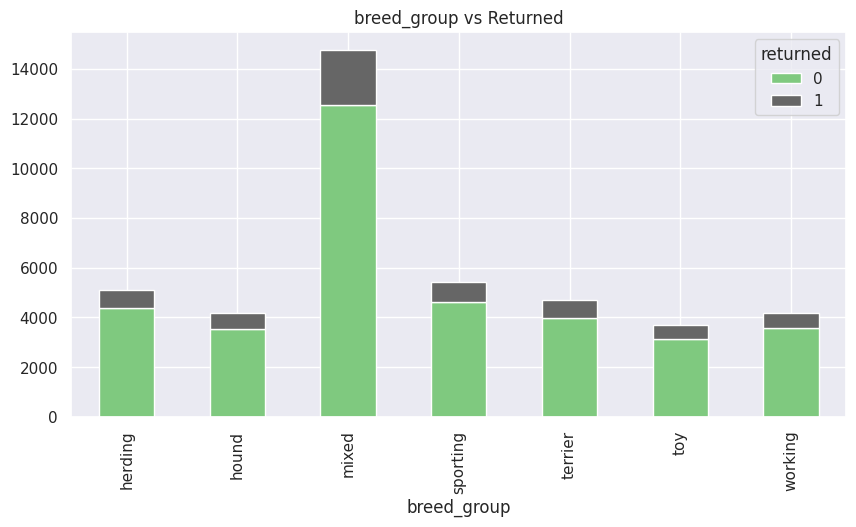

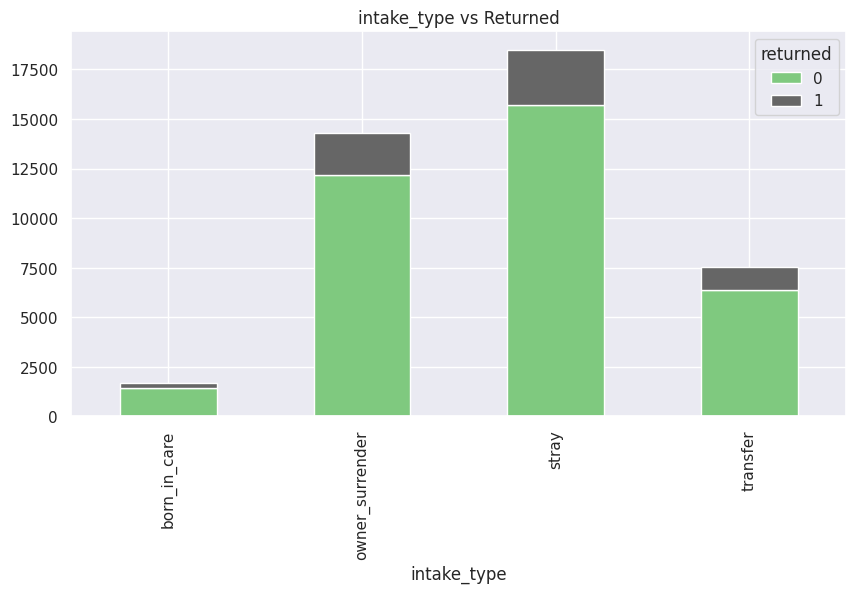

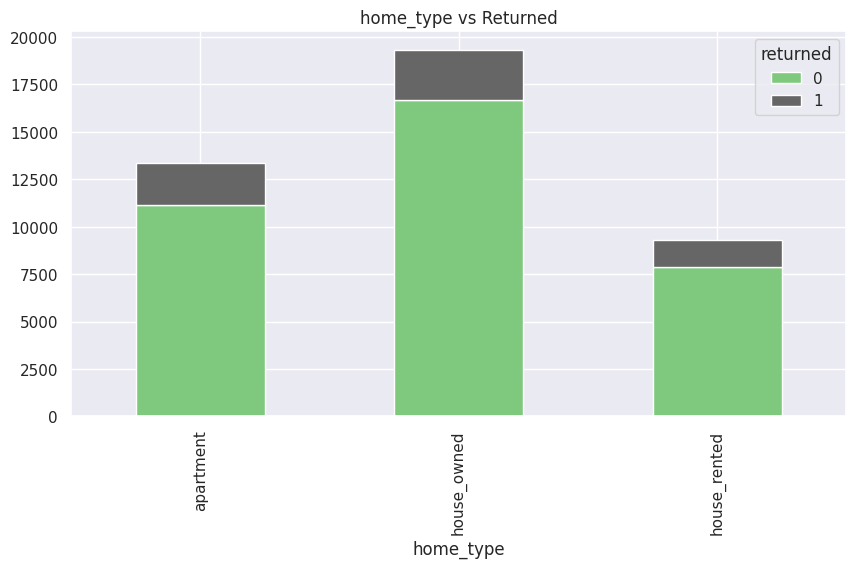

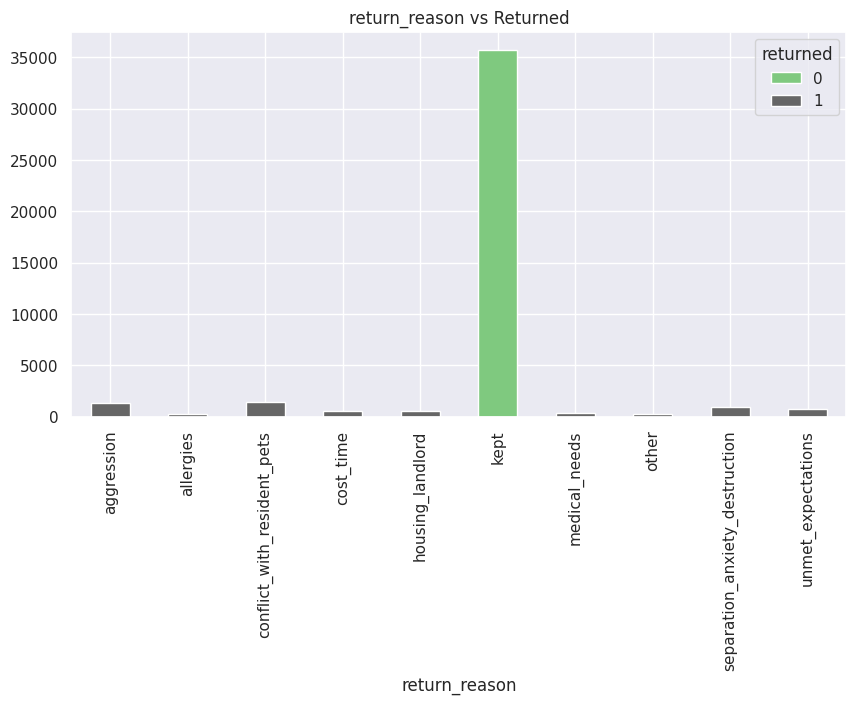

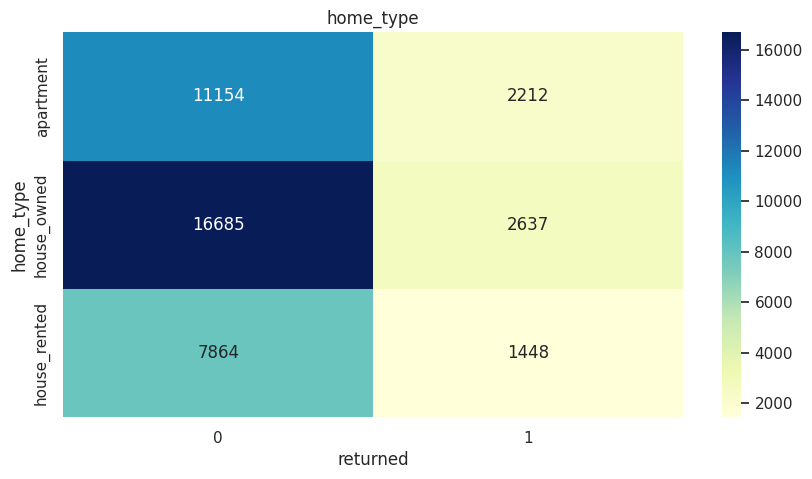

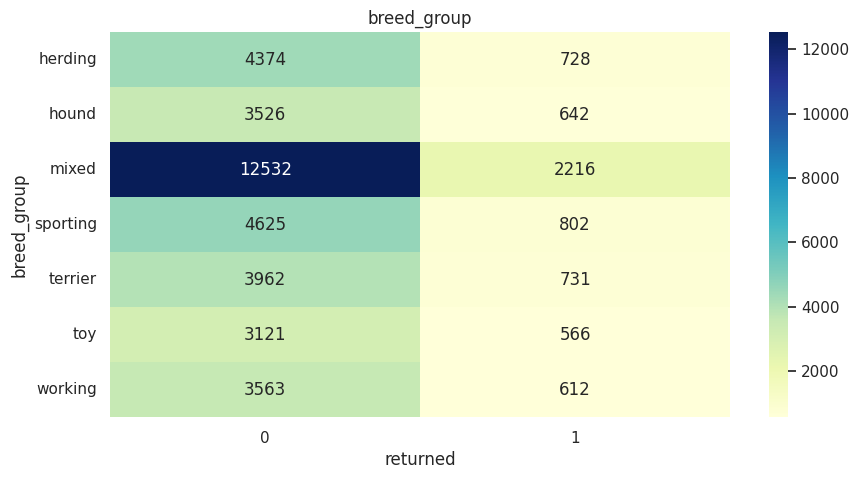

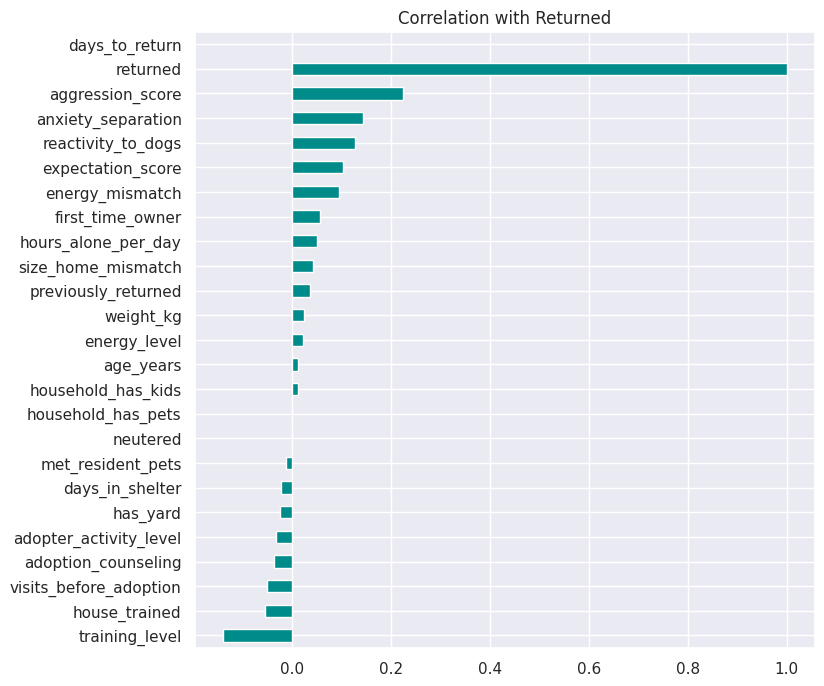

EDA Completed Successfully!


In [12]:
print(df.describe(include='all'))

# ------------------------------------------------------------
# Style
# ------------------------------------------------------------
plt.style.use("ggplot")
sns.set(font_scale=1)

# ------------------------------------------------------------
# Missing Values
# ------------------------------------------------------------
plt.figure(figsize=(14,6))
sns.heatmap(df.isnull(),
            cbar=False,
            cmap="viridis")
plt.title("Missing Values Heatmap",fontsize=18,color="darkred")
plt.show()

# ------------------------------------------------------------
# Missing Value Percentage
# ------------------------------------------------------------
missing = df.isnull().sum().sort_values(ascending=False)

plt.figure(figsize=(12,5))
missing.plot(kind="bar",
             color="tomato")
plt.title("Missing Values Count",fontsize=16)
plt.show()

# ============================================================
# TARGET VARIABLE
# ============================================================

plt.figure(figsize=(6,5))
sns.countplot(x="returned",
              data=df,
              palette="Set2")

plt.title("Returned Distribution",
          fontsize=18,
          color="darkblue")
plt.show()

# Pie Chart

df["returned"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    colors=["lightgreen","orange"],
    figsize=(6,6)
)
plt.ylabel("")
plt.title("Returned Percentage")
plt.show()

# ============================================================
# NUMERIC COLUMNS
# ============================================================

numeric_cols=df.select_dtypes(include=np.number).columns

print(numeric_cols)

# ============================================================
# HISTOGRAMS
# ============================================================

for col in numeric_cols:

    plt.figure(figsize=(7,4))

    sns.histplot(df[col],
                 bins=30,
                 kde=True,
                 color=np.random.choice([
                     "red","green","blue","purple",
                     "orange","brown","teal",
                     "magenta","navy","gold"
                 ]))

    plt.title(col)
    plt.show()

# ============================================================
# KDE DISTRIBUTION
# ============================================================

for col in numeric_cols:

    plt.figure(figsize=(7,4))

    sns.kdeplot(df[col],
                fill=True,
                color=np.random.choice([
                    "purple","green",
                    "red","orange",
                    "blue","black"
                ]))

    plt.title("Density Plot : "+col)

    plt.show()

# ============================================================
# BOXPLOTS
# ============================================================

for col in numeric_cols:

    plt.figure(figsize=(6,4))

    sns.boxplot(
        x=df[col],
        color=np.random.choice([
            "skyblue",
            "gold",
            "pink",
            "lime",
            "cyan",
            "orange"
        ])
    )

    plt.title("Boxplot : "+col)

    plt.show()

# ============================================================
# CORRELATION HEATMAP
# ============================================================

plt.figure(figsize=(18,12))

corr=df[numeric_cols].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix",
          fontsize=18)

plt.show()

# ============================================================
# CATEGORICAL COLUMNS
# ============================================================

cat_cols=df.select_dtypes(include="object").columns

print(cat_cols)

# ============================================================
# COUNTPLOTS
# ============================================================

colors=["Set1","Set2","Set3","Pastel1",
         "Dark2","Accent","Paired"]

for i,col in enumerate(cat_cols):

    plt.figure(figsize=(9,4))

    sns.countplot(
        y=col,
        data=df,
        palette=colors[i%len(colors)],
        order=df[col].value_counts().index
    )

    plt.title(col)

    plt.show()

# ============================================================
# PIE CHARTS
# ============================================================

for col in cat_cols:

    plt.figure(figsize=(6,6))

    df[col].value_counts().head(10).plot(
        kind="pie",
        autopct="%1.1f%%",
        cmap="tab20"
    )

    plt.ylabel("")

    plt.title(col)

    plt.show()

# ============================================================
# PAIRPLOT
# ============================================================

sns.pairplot(
    df[numeric_cols[:6]],
    corner=True,
    diag_kind="kde"
)

plt.show()

# ============================================================
# VIOLIN PLOTS
# ============================================================

important_numeric=[
    "age_years",
    "weight_kg",
    "days_in_shelter",
    "aggression_score",
    "energy_level",
    "expectation_score"
]

for col in important_numeric:

    if col in df.columns:

        plt.figure(figsize=(6,5))

        sns.violinplot(
            x="returned",
            y=col,
            data=df,
            palette="cool"
        )

        plt.title(col+" vs Returned")

        plt.show()

# ============================================================
# SCATTERPLOTS
# ============================================================

scatter_pairs=[
    ("age_years","weight_kg"),
    ("days_in_shelter","expectation_score"),
    ("aggression_score","energy_level"),
    ("hours_alone_per_day","anxiety_separation")
]

for x,y in scatter_pairs:

    if x in df.columns and y in df.columns:

        plt.figure(figsize=(7,5))

        sns.scatterplot(
            data=df,
            x=x,
            y=y,
            hue="returned",
            palette="Set1"
        )

        plt.title(x+" vs "+y)

        plt.show()

# ============================================================
# LINE CHART
# ============================================================

if "days_in_shelter" in df.columns:

    temp=df.sort_values("days_in_shelter")

    plt.figure(figsize=(12,5))

    plt.plot(
        temp["days_in_shelter"],
        temp["expectation_score"],
        color="purple"
    )

    plt.title("Days in Shelter vs Expectation Score")

    plt.xlabel("Days")

    plt.ylabel("Expectation Score")

    plt.show()

# ============================================================
# BARPLOTS
# ============================================================

important_cat=[
    "breed_group",
    "intake_type",
    "home_type",
    "return_reason"
]

for col in important_cat:

    if col in df.columns:

        plt.figure(figsize=(12,5))

        sns.countplot(
            y=col,
            hue="returned",
            data=df,
            palette="viridis"
        )

        plt.title(col+" vs Returned")

        plt.show()

# ============================================================
# STACKED BAR CHART
# ============================================================

for col in important_cat:

    if col in df.columns:

        pd.crosstab(
            df[col],
            df["returned"]
        ).plot(
            kind="bar",
            stacked=True,
            figsize=(10,5),
            colormap="Accent"
        )

        plt.title(col+" vs Returned")

        plt.show()

# ============================================================
# HEATMAP OF CROSSTAB
# ============================================================

for col in ["home_type","breed_group"]:

    if col in df.columns:

        plt.figure(figsize=(10,5))

        ct=pd.crosstab(df[col],df["returned"])

        sns.heatmap(
            ct,
            annot=True,
            cmap="YlGnBu",
            fmt="d"
        )

        plt.title(col)

        plt.show()

# ============================================================
# FEATURE IMPORTANCE STYLE CORRELATION
# ============================================================

corr_target=df.corr(numeric_only=True)["returned"].sort_values()

plt.figure(figsize=(8,8))

corr_target.plot(
    kind="barh",
    color="darkcyan"
)

plt.title("Correlation with Returned")

plt.show()

# ============================================================
# END OF EDA
# ============================================================

print("EDA Completed Successfully!")

## Feature engineering

In [13]:
missing_values = df.isnull().sum()
print('Missing values in each column:')
print(missing_values)

# For numerical columns, if missing, fill with median
num_cols = df.select_dtypes(include=[np.number]).columns
for col in num_cols:
    if df[col].isnull().sum() > 0:
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)

# For categorical columns, fill missing with the mode
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    if df[col].isnull().sum() > 0:
        mode_val = df[col].mode()[0]
        df[col].fillna(mode_val, inplace=True)

# Special note: If readers encounter errors with missing values, relying on median/mode 
# imputation is a robust starting point that minimizes the impact of outliers.

print('Data cleaning complete. Missing values have been handled.')

Missing values in each column:
adoption_id                   0
age_years                     0
size                          0
weight_kg                     0
breed_group                   0
intake_type                   0
days_in_shelter               0
previously_returned           0
medical_needs                 0
neutered                      0
aggression_score              0
anxiety_separation            0
reactivity_to_dogs            0
energy_level                  0
training_level                0
house_trained                 0
first_time_owner              0
household_has_kids            0
household_has_pets            0
home_type                     0
has_yard                      0
hours_alone_per_day           0
adopter_activity_level        0
visits_before_adoption        0
met_resident_pets             0
adoption_counseling           0
expectation_score             0
energy_mismatch               0
size_home_mismatch            0
return_reason                 0
days_to_r

Prediction Accuracy: 0.85


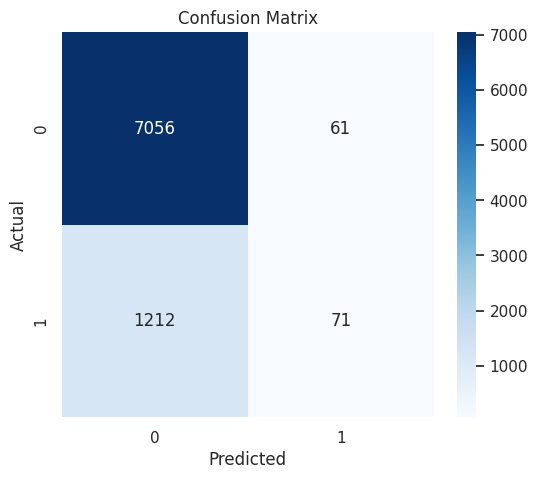

In [14]:
features = [
    'age_years', 'weight_kg', 'days_in_shelter', 'aggression_score',
    'anxiety_separation', 'reactivity_to_dogs', 'energy_level', 'training_level',
    'hours_alone_per_day', 'adopter_activity_level', 'visits_before_adoption',
    'expectation_score', 'energy_mismatch'
]

# Check if features exist in the dataframe
features = [col for col in features if col in df.columns]

# Our target variable is 'returned'
target = 'returned'

X = df[features]
y = df[target]

# Splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Instantiate and train the RandomForestClassifier
rfc = RandomForestClassifier(n_estimators=100, random_state=42)
rfc.fit(X_train, y_train)

# Predictions and evaluation
y_pred = rfc.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Prediction Accuracy: {accuracy:.2f}")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

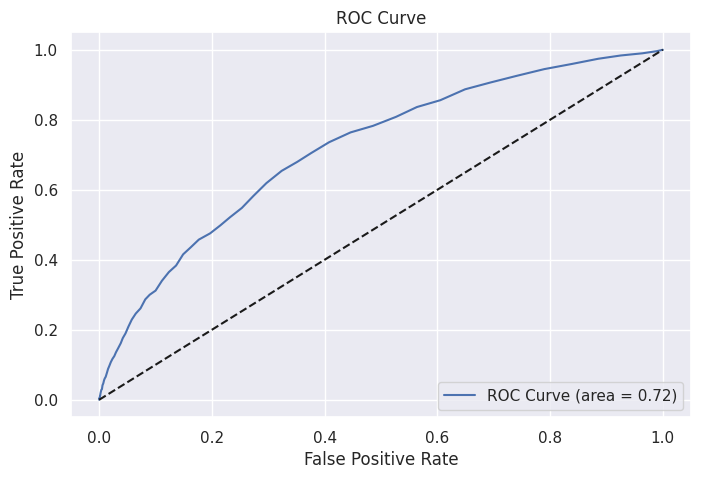

In [15]:
# ROC Curve
y_prob = rfc.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, label=f'ROC Curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.show()

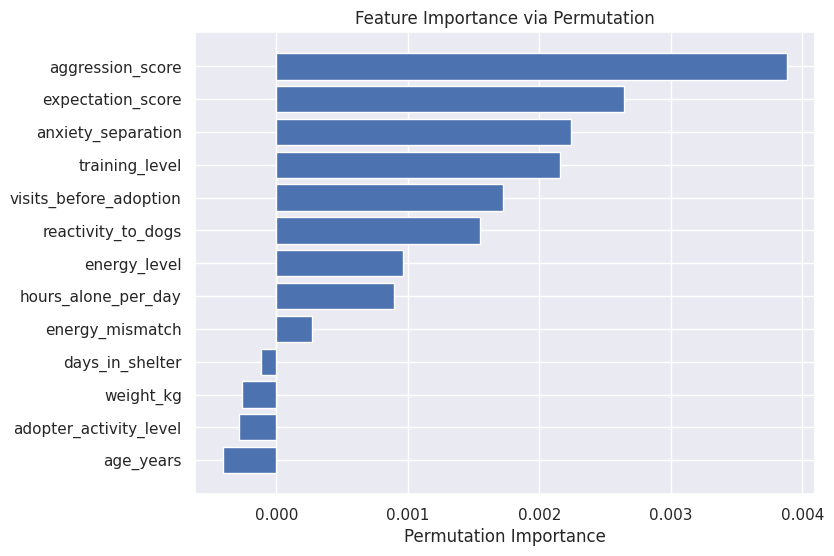

In [16]:
# Permutation Importance
result = permutation_importance(rfc, X_test, y_test, n_repeats=10, random_state=42)
sorted_idx = result.importances_mean.argsort()
plt.figure(figsize=(8, 6))
plt.barh(np.array(features)[sorted_idx], result.importances_mean[sorted_idx])
plt.xlabel('Permutation Importance')
plt.title('Feature Importance via Permutation')
plt.show()

## Thank you...pls upvote!!!!!!!!!!!!